In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, GridSearchCV,
                                     RandomizedSearchCV, learning_curve)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_auc_score,
                             roc_curve, precision_recall_curve,
                             ConfusionMatrixDisplay, average_precision_score)
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline

import xgboost as xgb
from xgboost import XGBClassifier, plot_importance, plot_tree

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120

In [2]:
path = kagglehub.dataset_download(
    "mlg-ulb/creditcardfraud")
print("📁 Path:", path)

csv_file = os.path.join(path, "creditcard.csv")
df = pd.read_csv(csv_file)

print(f"\n✅ Dataset Loaded!")
print(f"📐 Shape: {df.shape[0]:,} rows × "
      f"{df.shape[1]} columns")
df.head()

Using Colab cache for faster access to the 'creditcardfraud' dataset.
📁 Path: /kaggle/input/creditcardfraud

✅ Dataset Loaded!
📐 Shape: 284,807 rows × 31 columns


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [7]:
num_cols = df.select_dtypes(
    include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(
    include=['object']).columns.tolist()

print(f"\n🔢 Numerical ({len(num_cols)}): "
      f"{num_cols[:5]}...{num_cols[-3:]}")
print(f"\n🔤 Categorical ({len(cat_cols)}): "
      f"{cat_cols}")

print(f"\n🎯 Target: Class (Fraud Detection)")
print(df['Class'].value_counts())

fraud_rate = df['Class'].mean() * 100
print(f"\n⚠️  Fraud Rate    : {fraud_rate:.4f}%")
print(f"✅  Legit Rate    : {100-fraud_rate:.4f}%")



🔢 Numerical (31): ['Time', 'V1', 'V2', 'V3', 'V4']...['V28', 'Amount', 'Class']

🔤 Categorical (0): []

🎯 Target: Class (Fraud Detection)
Class
0    284315
1       492
Name: count, dtype: int64

⚠️  Fraud Rate    : 0.1727%
✅  Legit Rate    : 99.8273%


In [8]:
print("🔍 Missing Values:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("✅ No missing values!")
else:
    print(missing[missing > 0])
    df.fillna(df.median(numeric_only=True),
               inplace=True)
    print("✅ Filled with median")

🔍 Missing Values:
✅ No missing values!


In [9]:
dups = df.duplicated().sum()
print(f"\n🔍 Duplicate rows: {dups:,}")
if dups > 0:
    df.drop_duplicates(inplace=True)
    print(f"✅ {dups:,} duplicates removed!")
else:
    print("✅ No duplicates found!")


🔍 Duplicate rows: 1,081
✅ 1,081 duplicates removed!


In [10]:
useless = [c for c in df.columns
           if df[c].nunique() == 1]
if useless:
    df.drop(columns=useless, inplace=True)
    print(f"✅ Dropped constant cols: {useless}")
else:
    print("✅ No constant columns!")

✅ No constant columns!


In [11]:
print("\n🔍 Outlier Detection (IQR):")
feat_cols = [c for c in df.columns
             if c not in ['Class', 'Time']]
outlier_info = {}

for col in feat_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    out = df[(df[col] < Q1 - 3*IQR) |
             (df[col] > Q3 + 3*IQR)].shape[0]
    if out > 0:
        outlier_info[col] = out

print(f"  Columns with extreme outliers "
      f"(3×IQR): {len(outlier_info)}")

# Cap extreme outliers only (3x IQR)
for col in outlier_info.keys():
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(
        lower=Q1 - 3*IQR,
        upper=Q3 + 3*IQR)
print("✅ Extreme outliers capped (3×IQR)")

print(f"\n📐 Cleaned Shape: {df.shape}")
df.head(3)


🔍 Outlier Detection (IQR):
  Columns with extreme outliers (3×IQR): 29
✅ Extreme outliers capped (3×IQR)

📐 Cleaned Shape: (283726, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,293.24,0


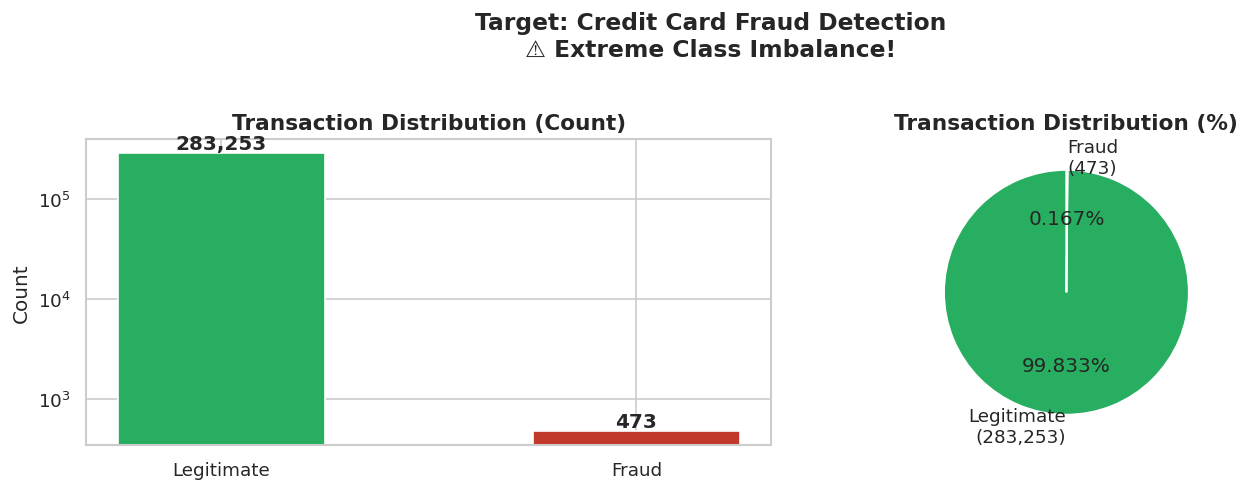

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

class_counts = df['Class'].value_counts()
labels       = ['Legitimate', 'Fraud']

axes[0].bar(labels,
            class_counts.values,
            color=['#27ae60', '#c0392b'],
            edgecolor='white', width=0.5)
axes[0].set_title('Transaction Distribution (Count)',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_yscale('log')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v * 1.1, f'{v:,}',
                 ha='center', fontweight='bold')

axes[1].pie([class_counts[0], class_counts[1]],
            labels=['Legitimate\n'
                    f'({class_counts[0]:,})',
                    'Fraud\n'
                    f'({class_counts[1]:,})'],
            autopct='%1.3f%%',
            colors=['#27ae60', '#c0392b'],
            startangle=90,
            wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Transaction Distribution (%)',
                  fontsize=13, fontweight='bold')

plt.suptitle('Target: Credit Card Fraud Detection\n'
             '⚠️ Extreme Class Imbalance!',
             fontsize=14, fontweight='bold',
             y=1.02)
plt.tight_layout()
plt.savefig('XGB_01_class_distribution.png',
            bbox_inches='tight')
plt.show()

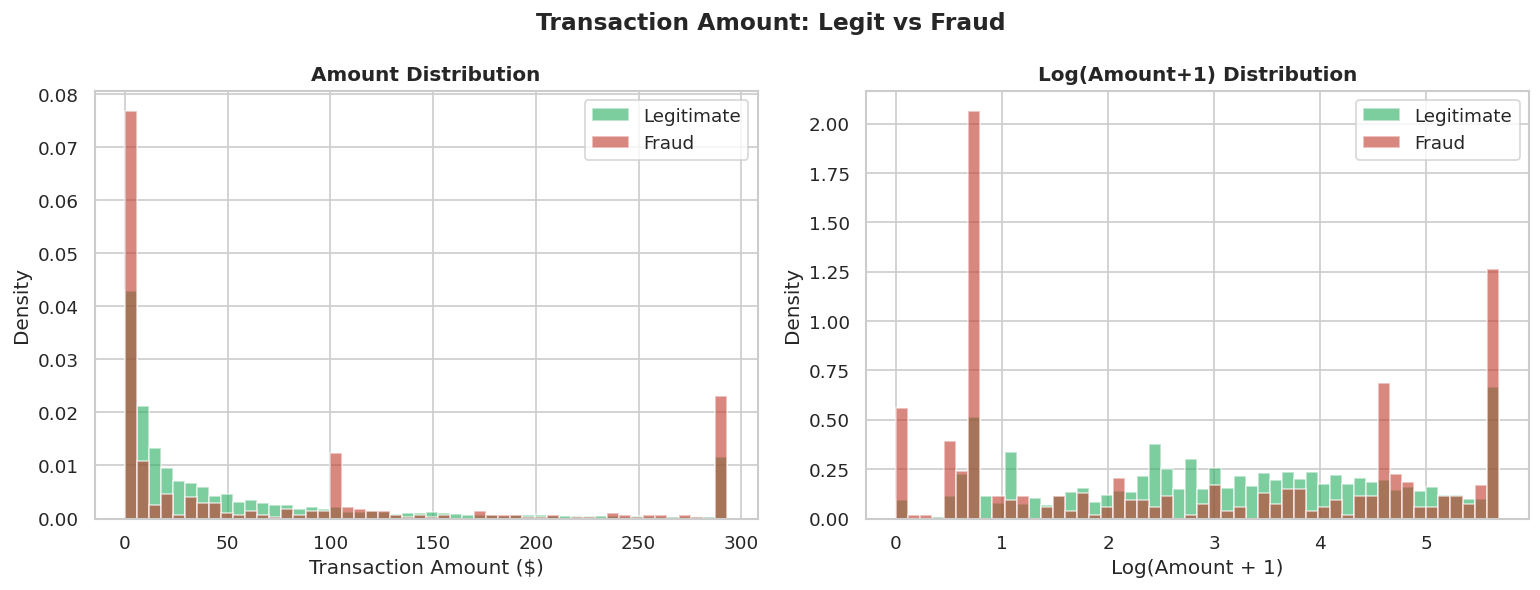

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for label, color, name in zip(
        [0, 1],
        ['#27ae60', '#c0392b'],
        ['Legitimate', 'Fraud']):
    axes[0].hist(
        df[df['Class']==label]['Amount'],
        bins=50, alpha=0.6,
        color=color, label=name,
        density=True)
    axes[1].hist(
        np.log1p(df[df['Class']==label]['Amount']),
        bins=50, alpha=0.6,
        color=color, label=name,
        density=True)

axes[0].set_title('Amount Distribution',
                  fontweight='bold', fontsize=12)
axes[0].set_xlabel('Transaction Amount ($)')
axes[0].set_ylabel('Density')
axes[0].legend()

axes[1].set_title('Log(Amount+1) Distribution',
                  fontweight='bold', fontsize=12)
axes[1].set_xlabel('Log(Amount + 1)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.suptitle('Transaction Amount: Legit vs Fraud',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('XGB_02_amount_distribution.png',
            bbox_inches='tight')
plt.show()

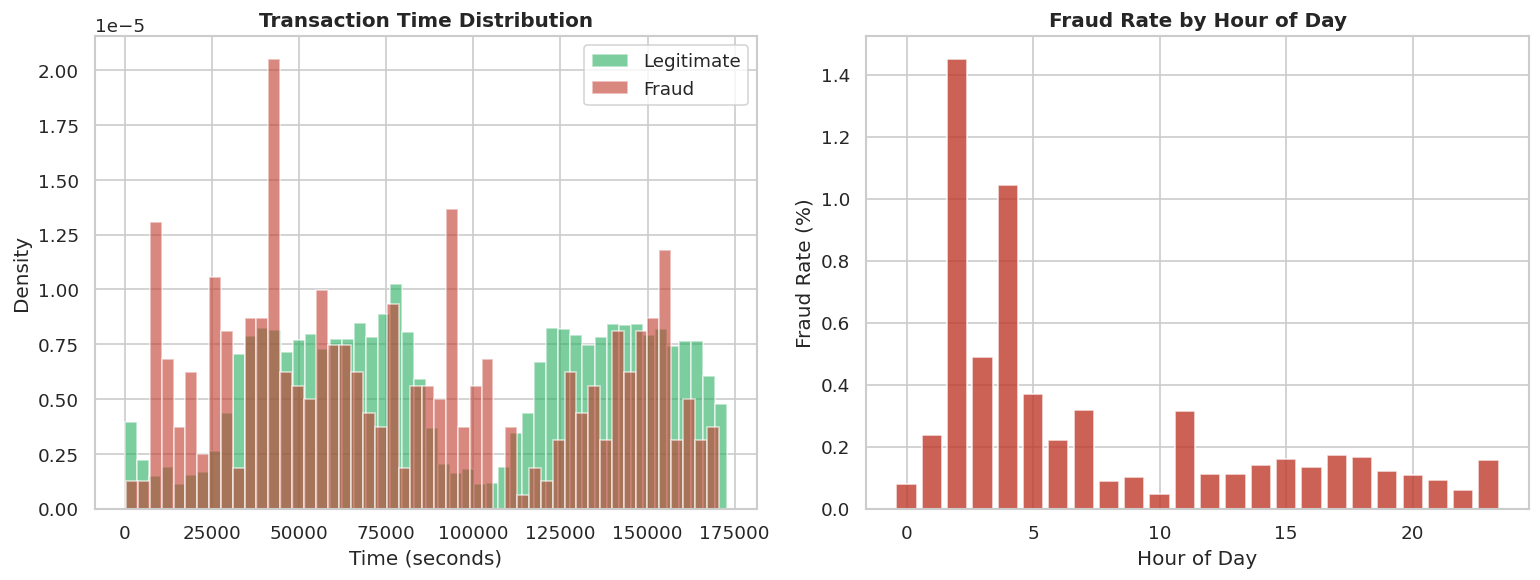

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for label, color, name in zip(
        [0, 1],
        ['#27ae60', '#c0392b'],
        ['Legitimate', 'Fraud']):
    axes[0].hist(
        df[df['Class']==label]['Time'],
        bins=50, alpha=0.6,
        color=color, label=name,
        density=True)

axes[0].set_title('Transaction Time Distribution',
                  fontweight='bold', fontsize=12)
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Fraud by hour
df['Hour'] = (df['Time'] // 3600) % 24
fraud_by_hour = df.groupby('Hour')['Class'].agg(
    ['sum', 'count'])
fraud_by_hour['rate'] = (fraud_by_hour['sum'] /
                          fraud_by_hour['count'] * 100)

axes[1].bar(fraud_by_hour.index,
            fraud_by_hour['rate'],
            color='#c0392b', edgecolor='white',
            alpha=0.8)
axes[1].set_title('Fraud Rate by Hour of Day',
                  fontweight='bold', fontsize=12)
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Fraud Rate (%)')

plt.tight_layout()
plt.savefig('XGB_03_time_analysis.png',
            bbox_inches='tight')
plt.show()

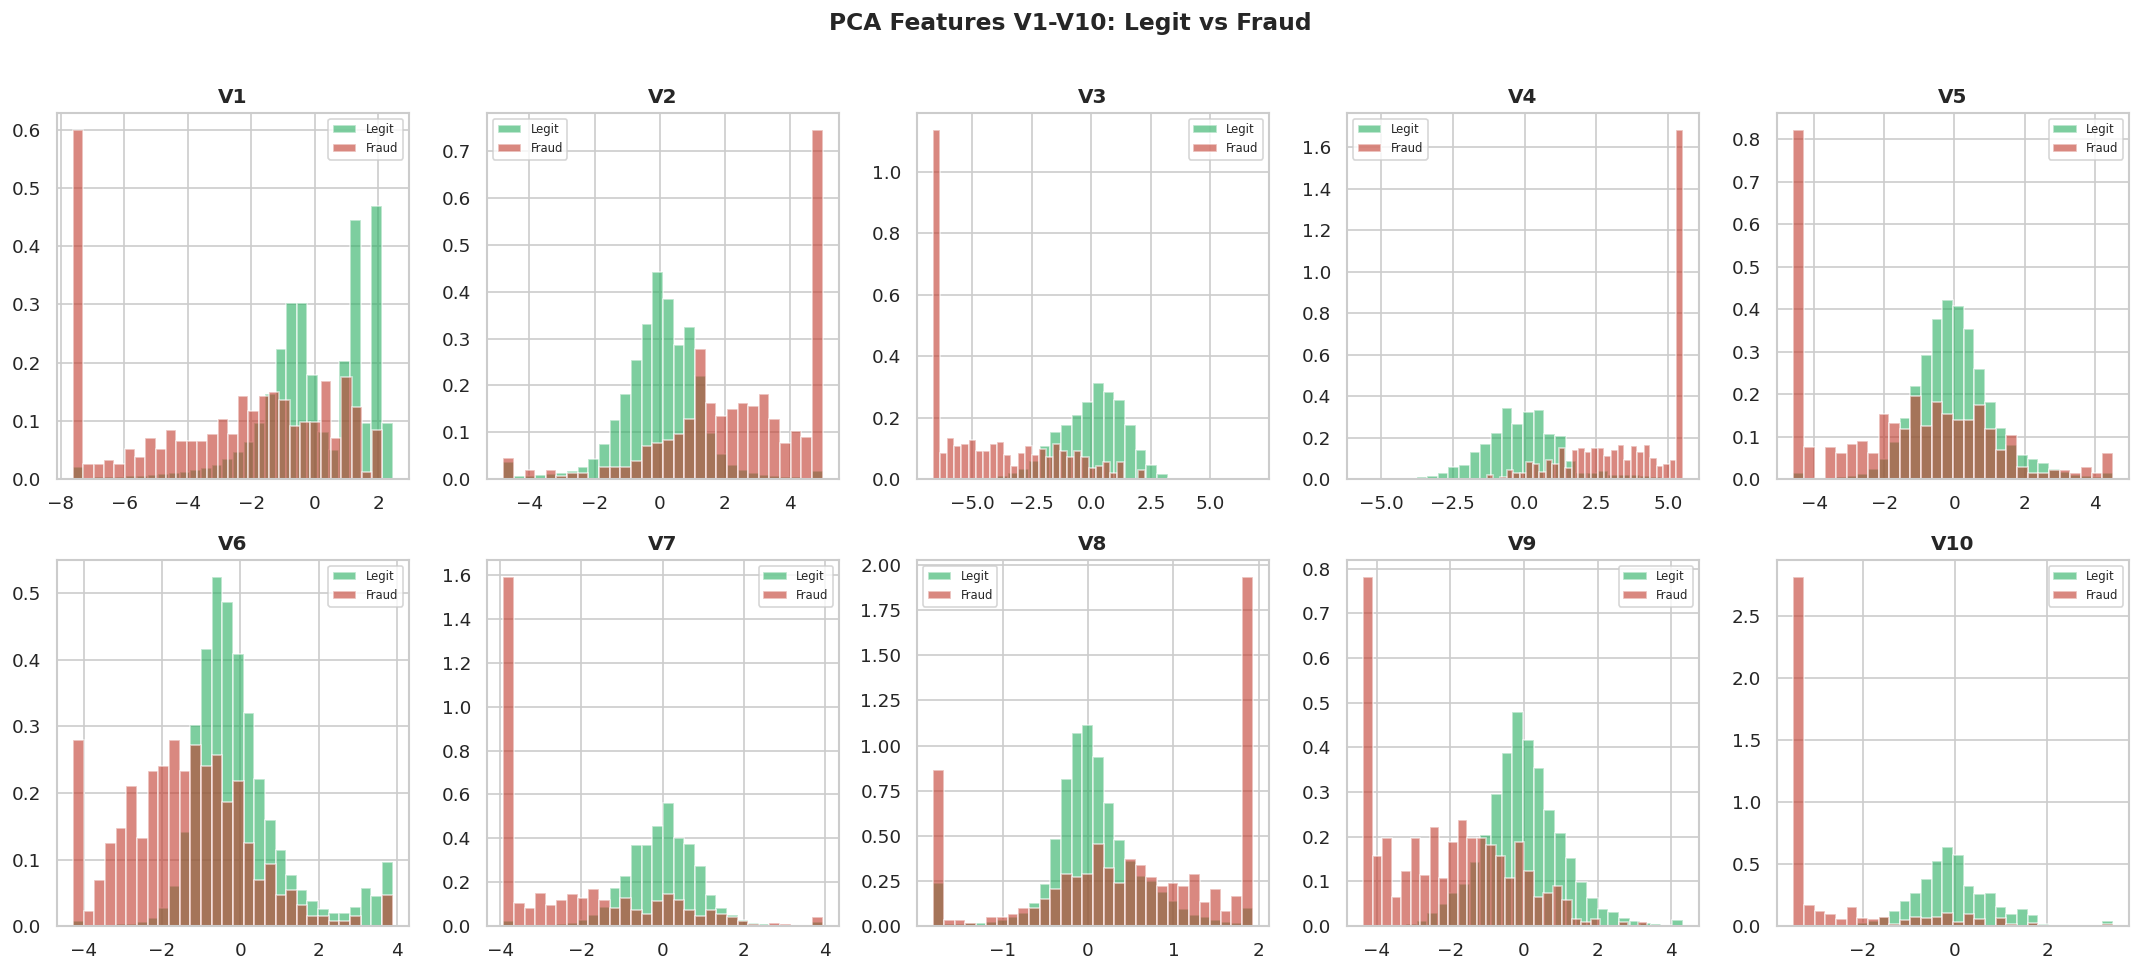

In [15]:
v_cols = [f'V{i}' for i in range(1, 11)]

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(v_cols):
    for label, color, name in zip(
            [0, 1],
            ['#27ae60', '#c0392b'],
            ['Legit', 'Fraud']):
        axes[i].hist(
            df[df['Class']==label][col],
            bins=30, alpha=0.6,
            color=color, label=name,
            density=True)
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=7)

plt.suptitle('PCA Features V1-V10: Legit vs Fraud',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('XGB_04_pca_features.png',
            bbox_inches='tight')
plt.show()

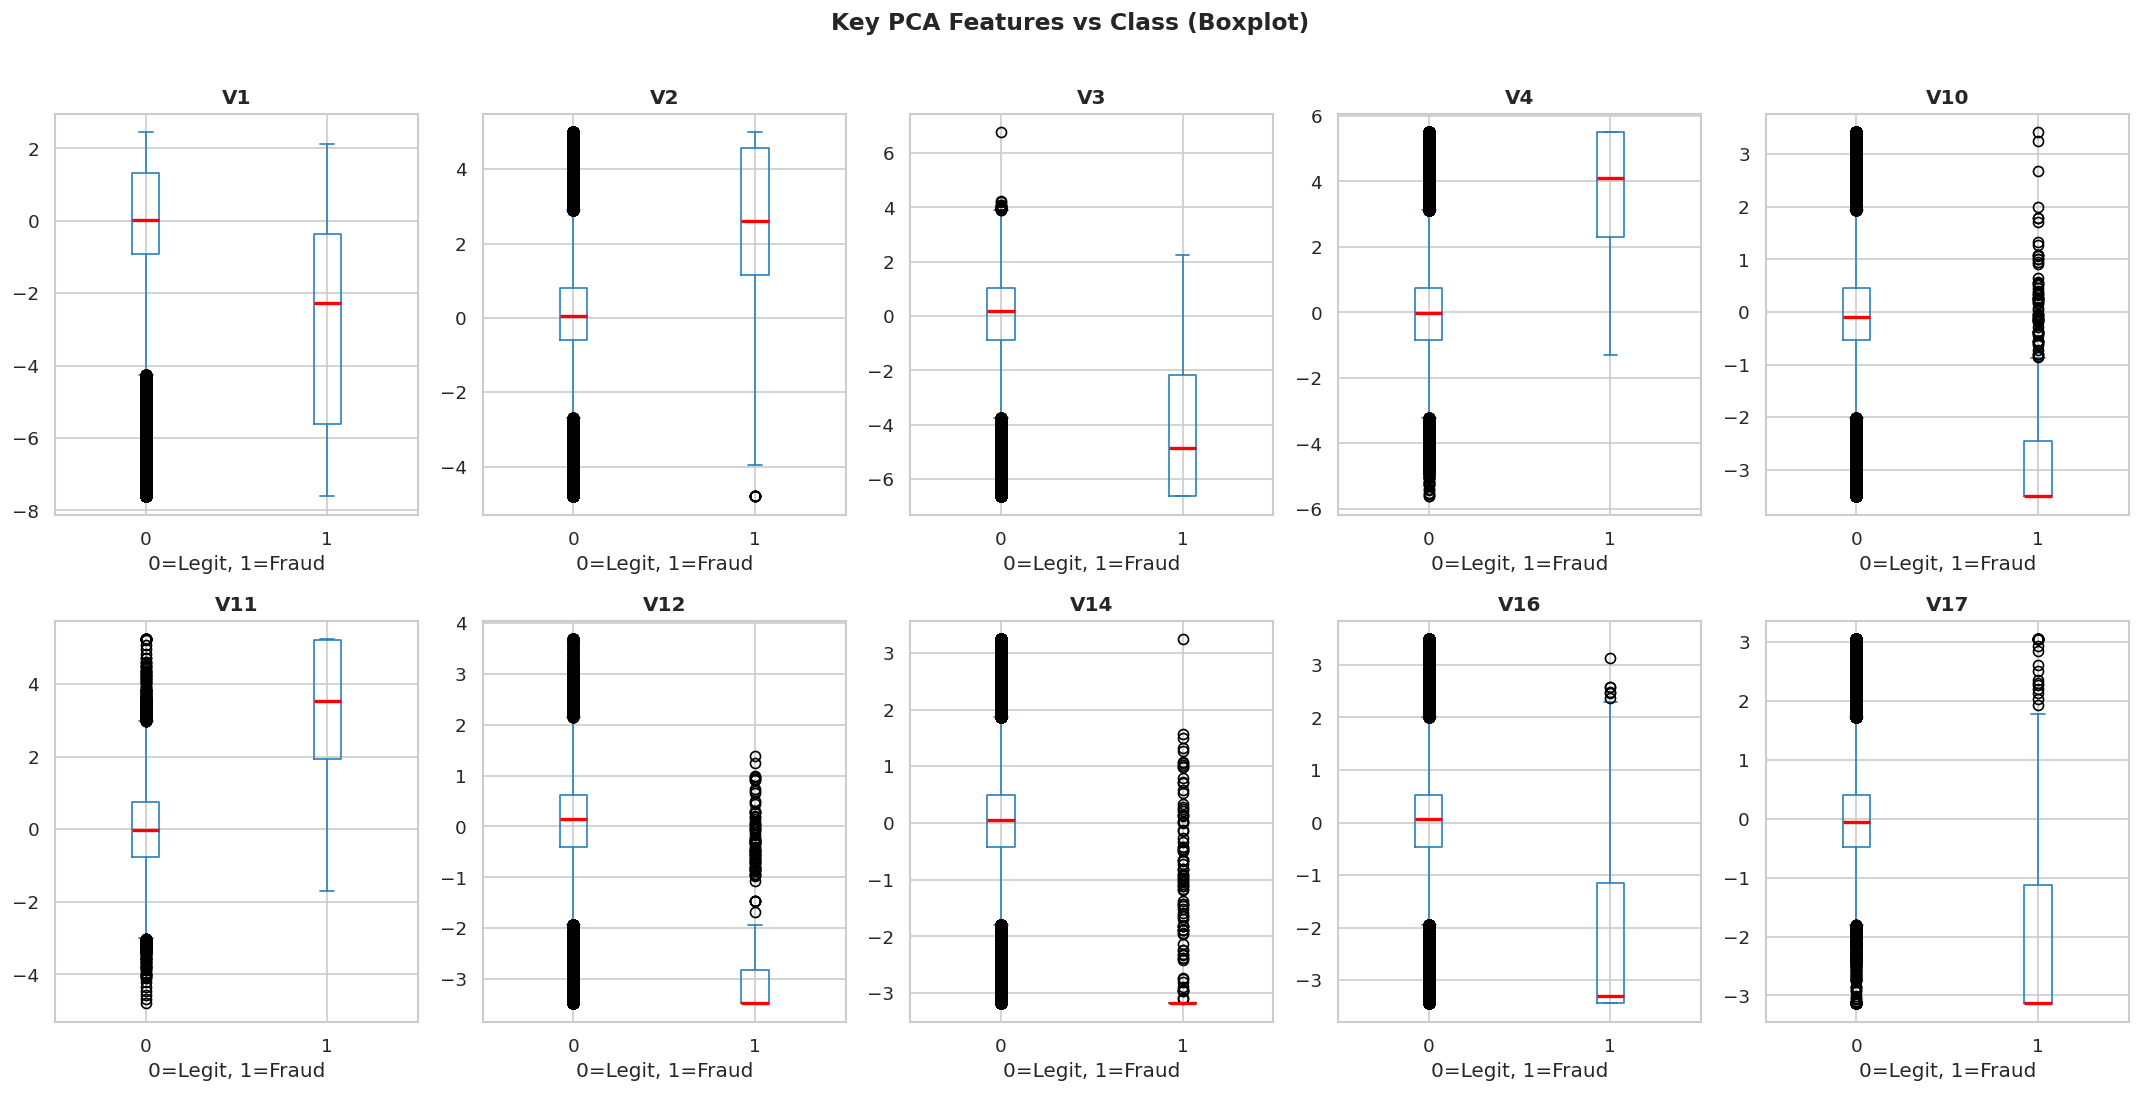

In [16]:
key_v_cols = ['V1', 'V2', 'V3', 'V4',
               'V10', 'V11', 'V12', 'V14',
               'V16', 'V17']

fig, axes = plt.subplots(2, 5, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(key_v_cols):
    df.boxplot(column=col, by='Class',
               ax=axes[i],
               boxprops=dict(color='#2980b9'),
               medianprops=dict(color='red',
                                linewidth=2),
               whiskerprops=dict(color='#2980b9'),
               capprops=dict(color='#2980b9'))
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('0=Legit, 1=Fraud')

plt.suptitle('Key PCA Features vs Class (Boxplot)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('XGB_05_boxplots.png',
            bbox_inches='tight')
plt.show()

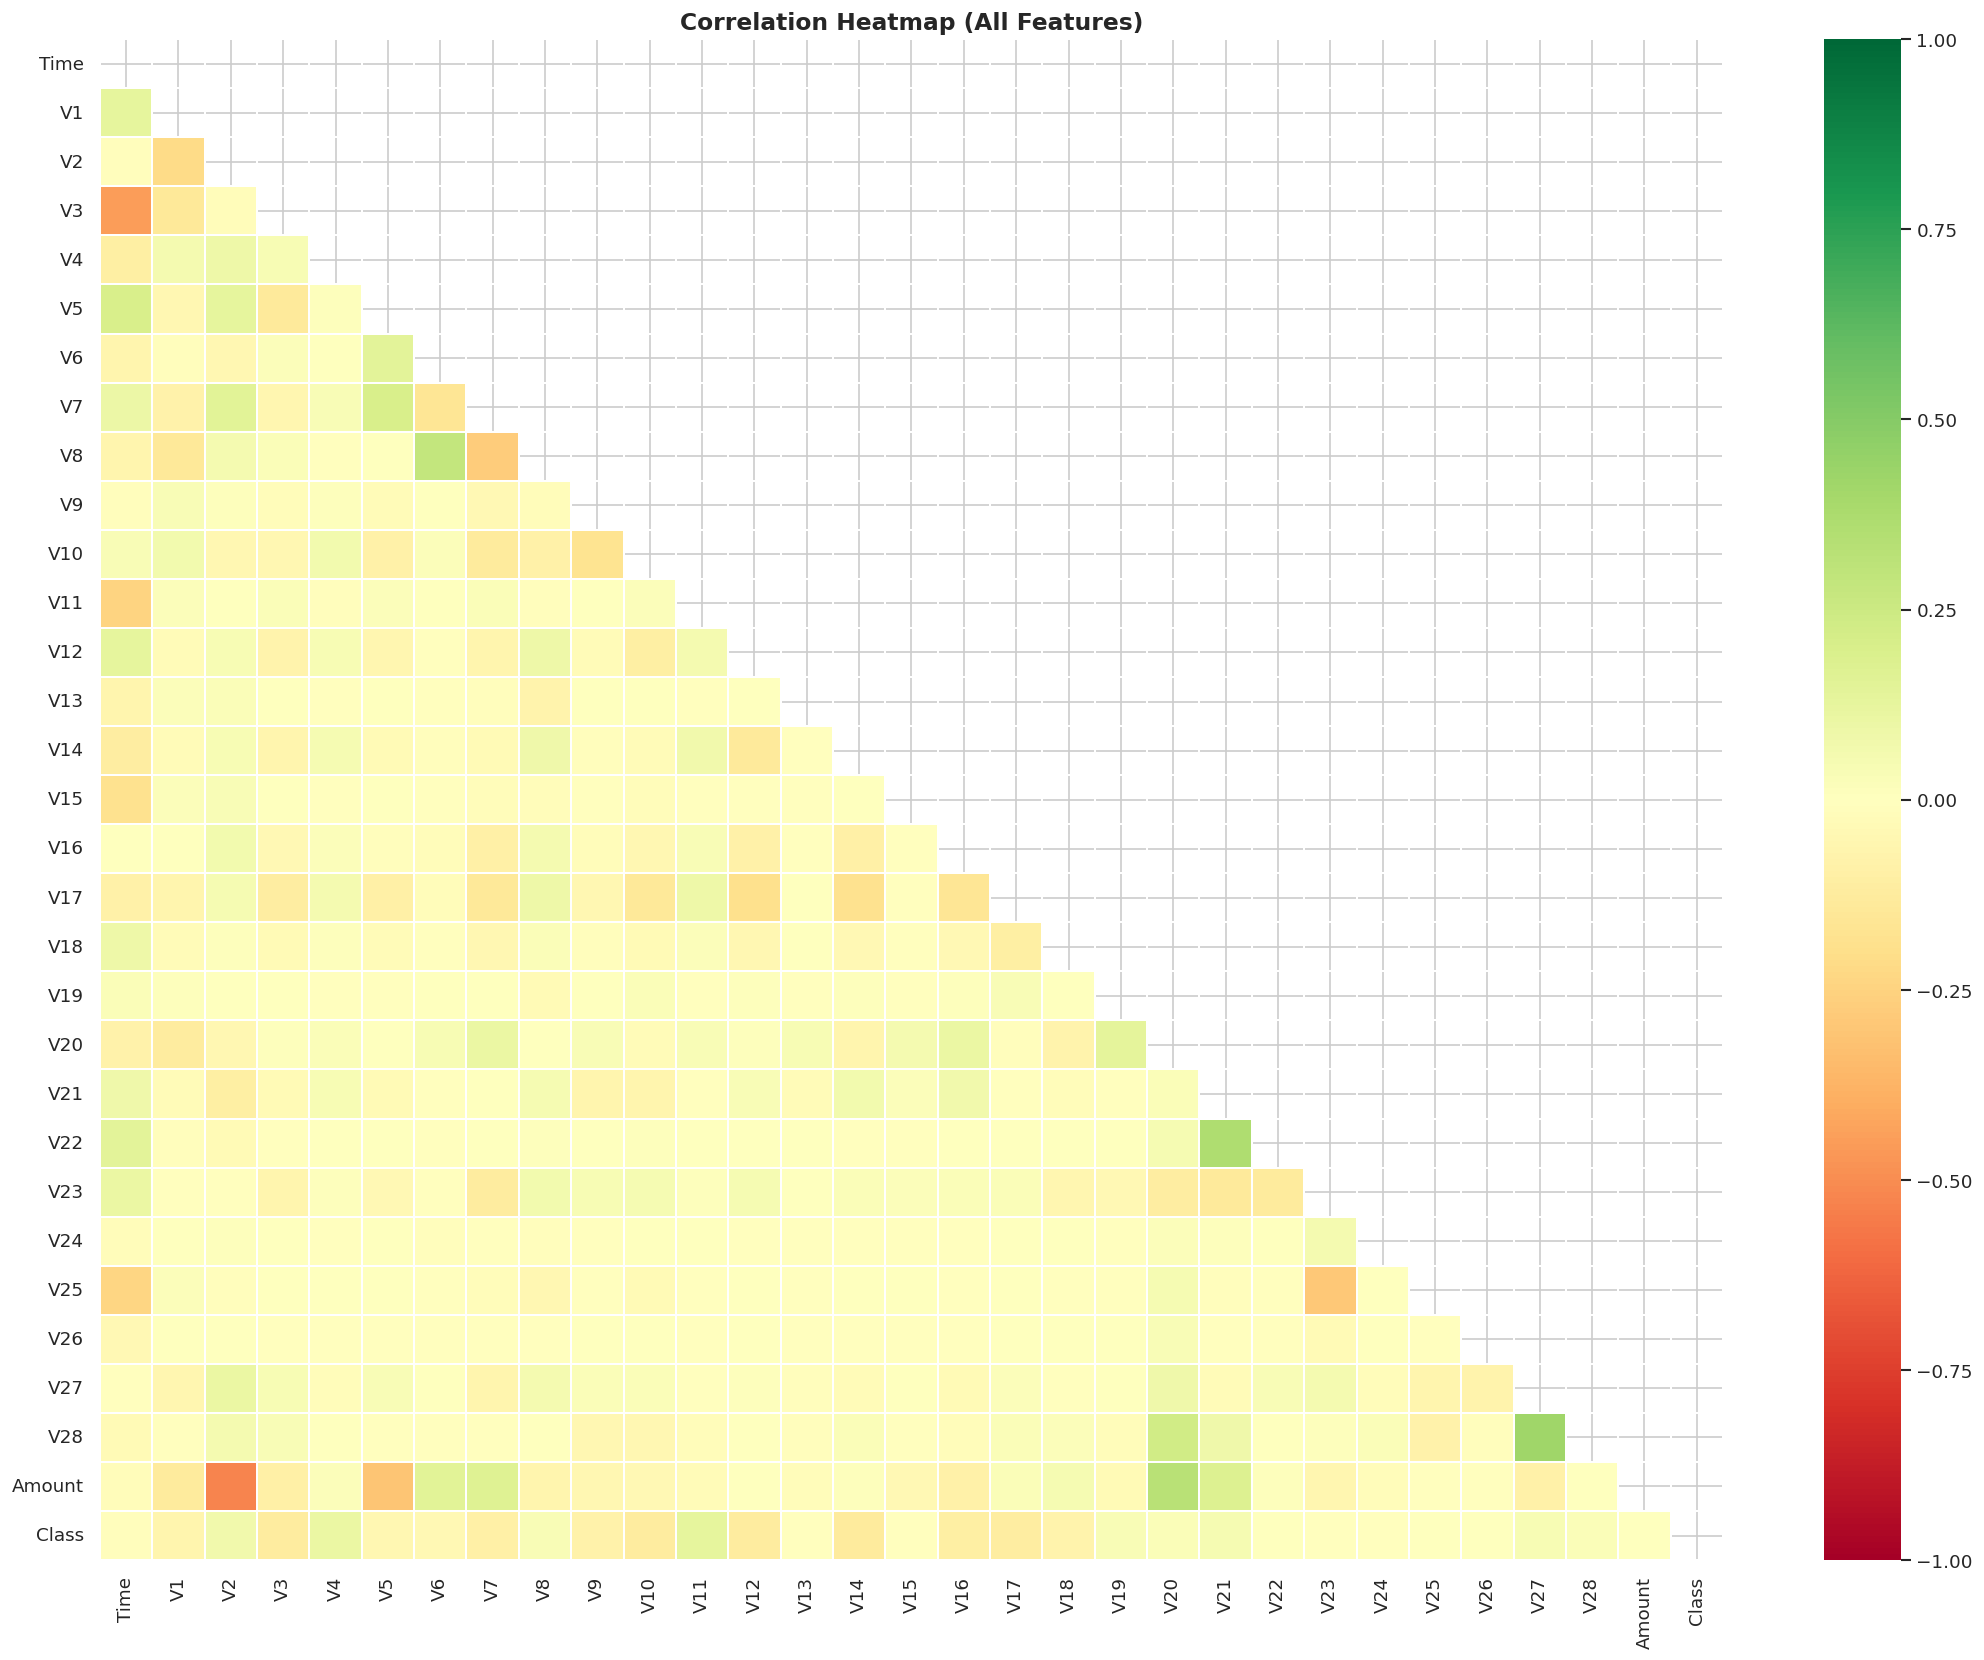

In [17]:
fig, ax = plt.subplots(figsize=(18, 14))

corr = df.drop(columns=['Hour']).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask,
            annot=False,
            cmap='RdYlGn',
            linewidths=0.1,
            ax=ax,
            vmin=-1, vmax=1,
            center=0)
ax.set_title('Correlation Heatmap (All Features)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('XGB_06_correlation_heatmap.png',
            bbox_inches='tight')
plt.show()

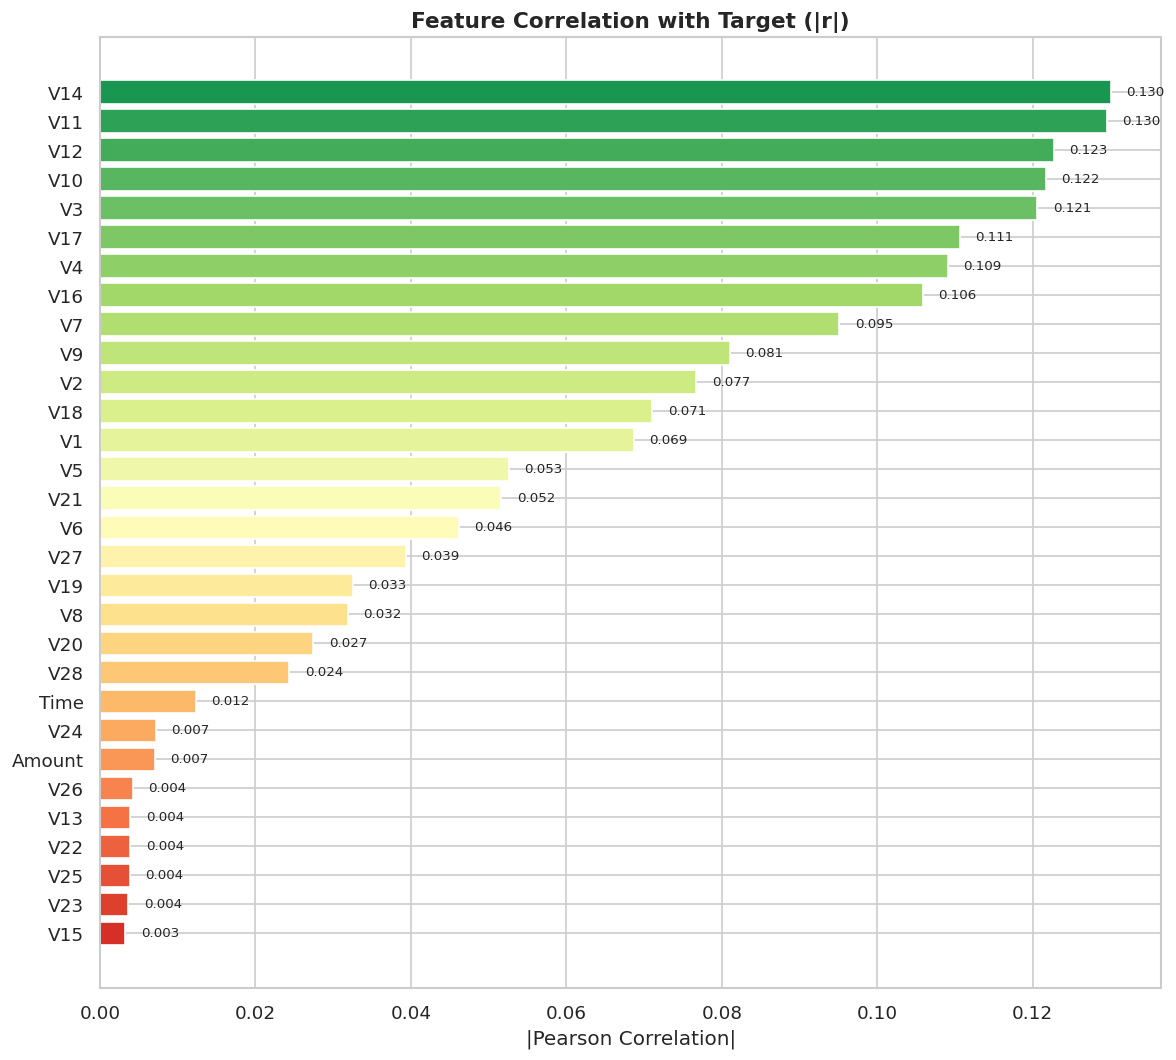

In [18]:
feat_corr = df.drop(
    columns=['Hour']
).corr()['Class'].drop('Class').abs().sort_values(
    ascending=False)

fig, ax = plt.subplots(figsize=(10, 9))
colors = plt.cm.RdYlGn(
    np.linspace(0.1, 0.9, len(feat_corr)))[::-1]

bars = ax.barh(feat_corr.index,
               feat_corr.values,
               color=colors,
               edgecolor='white')
ax.set_title('Feature Correlation with Target (|r|)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('|Pearson Correlation|')
ax.invert_yaxis()

for bar, val in zip(bars, feat_corr.values):
    ax.text(bar.get_width() + 0.002,
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}',
            va='center', fontsize=8)

plt.tight_layout()
plt.savefig('XGB_07_feature_correlation.png',
            bbox_inches='tight')
plt.show()

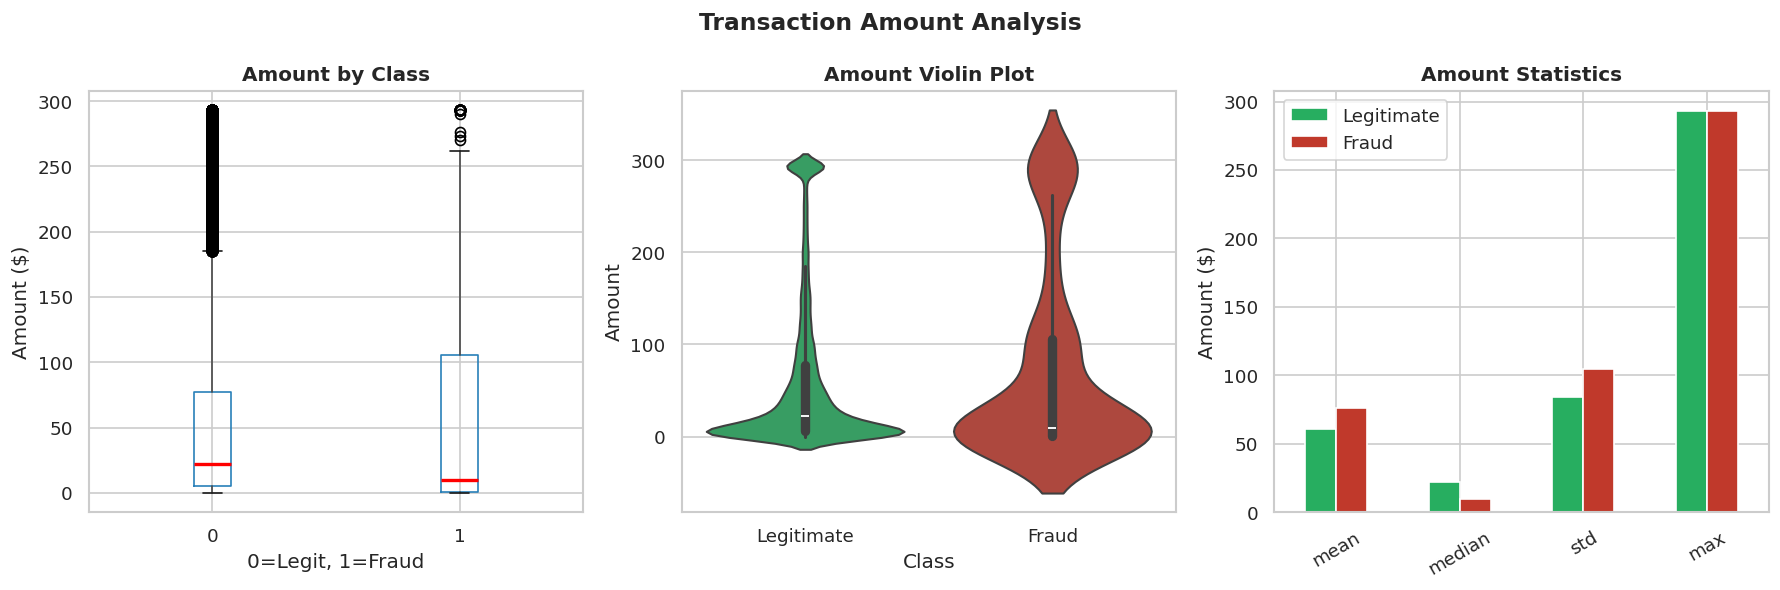

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Boxplot
df.boxplot(column='Amount', by='Class',
           ax=axes[0],
           boxprops=dict(color='#2980b9'),
           medianprops=dict(color='red',
                            linewidth=2))
axes[0].set_title('Amount by Class',
                  fontweight='bold')
axes[0].set_xlabel('0=Legit, 1=Fraud')
axes[0].set_ylabel('Amount ($)')

# Violin
df_plot = df[['Amount', 'Class']].copy()
df_plot['Class'] = df_plot['Class'].map(
    {0: 'Legitimate', 1: 'Fraud'})
sns.violinplot(data=df_plot,
               x='Class', y='Amount',
               palette=['#27ae60', '#c0392b'],
               ax=axes[1], inner='box')
axes[1].set_title('Amount Violin Plot',
                  fontweight='bold')

# Stats comparison
stats = df.groupby('Class')['Amount'].agg(
    ['mean', 'median', 'std', 'max'])
stats.index = ['Legitimate', 'Fraud']
stats.T.plot(kind='bar', ax=axes[2],
             color=['#27ae60', '#c0392b'],
             edgecolor='white')
axes[2].set_title('Amount Statistics',
                  fontweight='bold')
axes[2].set_ylabel('Amount ($)')
axes[2].tick_params(axis='x', rotation=30)
axes[2].legend()

plt.suptitle('Transaction Amount Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('XGB_08_amount_analysis.png',
            bbox_inches='tight')
plt.show()

In [20]:
df_model = df.copy()

# ── 6.1 Drop Hour (engineered but not needed)
df_model.drop(columns=['Hour'], inplace=True)

# ── 6.2 Scale Amount & Time
# (V1-V28 already PCA scaled)
scaler_amount = StandardScaler()
df_model['Amount_scaled'] = scaler_amount.fit_transform(
    df_model[['Amount']])
df_model['Time_scaled']   = StandardScaler(
    ).fit_transform(df_model[['Time']])

df_model.drop(columns=['Amount', 'Time'],
              inplace=True)
print("✅ Amount & Time scaled (StandardScaler)")
print("✅ Original Amount & Time dropped")

# ── 6.3 No categorical features
cat_remaining = df_model.select_dtypes(
    include='object').columns.tolist()
print(f"✅ Categorical cols: "
      f"{cat_remaining if cat_remaining else 'None'}")

# ── 6.4 Handle nulls
df_model.fillna(
    df_model.median(numeric_only=True),
    inplace=True)

print(f"\n📐 Shape after preprocessing: {df_model.shape}")
df_model.head(3)

✅ Amount & Time scaled (StandardScaler)
✅ Original Amount & Time dropped
✅ Categorical cols: None

📐 Shape after preprocessing: (283726, 31)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,Amount_scaled,Time_scaled
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,1.048385,-1.996823
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.692376,-1.996823
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,2.749931,-1.996802


In [21]:
df_model['Amount_log'] = np.log1p(
    scaler_amount.inverse_transform(
        df_model[['Amount_scaled']]).flatten())
print("✅ 'Amount_log' (log1p transform) created")

# V features mean & std
v_cols_all = [f'V{i}' for i in range(1, 29)
              if f'V{i}' in df_model.columns]

df_model['V_mean'] = df_model[v_cols_all].mean(
    axis=1)
print("✅ 'V_mean' (mean of V features) created")

df_model['V_std']  = df_model[v_cols_all].std(
    axis=1)
print("✅ 'V_std' (std of V features) created")

# Key fraud indicators (high corr with target)
df_model['fraud_indicator'] = (
    df_model['V14'].abs() +
    df_model['V12'].abs() +
    df_model['V10'].abs() +
    df_model['V17'].abs())
print("✅ 'fraud_indicator' created (V14+V12+V10+V17)")

# V17 × V14 interaction
df_model['V17_V14_interact'] = (
    df_model['V17'] * df_model['V14'])
print("✅ 'V17_V14_interact' created")

# V1 × V3 interaction
df_model['V1_V3_interact'] = (
    df_model['V1'] * df_model['V3'])
print("✅ 'V1_V3_interact' created")

print(f"\n📐 Final Shape: {df_model.shape}")

✅ 'Amount_log' (log1p transform) created
✅ 'V_mean' (mean of V features) created
✅ 'V_std' (std of V features) created
✅ 'fraud_indicator' created (V14+V12+V10+V17)
✅ 'V17_V14_interact' created
✅ 'V1_V3_interact' created

📐 Final Shape: (283726, 37)


In [22]:
X = df_model.drop(columns=['Class'])
y = df_model['Class']

print(f"🎯 Target distribution:")
print(f"   Legitimate (0): {(y==0).sum():,}")
print(f"   Fraud (1)     : {(y==1).sum():,}")
print(f"   Fraud Rate    : {y.mean()*100:.4f}%")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y)

print(f"\n✅ Training set : {X_train.shape}")
print(f"✅ Test set     : {X_test.shape}")
print(f"✅ Features     : {X_train.shape[1]}")

# Calculate scale_pos_weight for XGBoost
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

print(f"\n📌 scale_pos_weight = {scale_pos_weight:.2f}")
print(f"   (Handles class imbalance in XGBoost)")

🎯 Target distribution:
   Legitimate (0): 283,253
   Fraud (1)     : 473
   Fraud Rate    : 0.1667%

✅ Training set : (226980, 36)
✅ Test set     : (56746, 36)
✅ Features     : 36

📌 scale_pos_weight = 599.48
   (Handles class imbalance in XGBoost)


In [23]:
xgb_baseline = XGBClassifier(
    n_estimators      = 100,
    learning_rate     = 0.1,
    max_depth         = 6,
    scale_pos_weight  = scale_pos_weight,
    use_label_encoder = False,
    eval_metric       = 'auc',
    random_state      = 42,
    n_jobs            = -1)

xgb_baseline.fit(X_train, y_train,
                 eval_set=[(X_test, y_test)],
                 verbose=False)

y_pred_base = xgb_baseline.predict(X_test)
y_prob_base = xgb_baseline.predict_proba(
    X_test)[:, 1]

acc_base = accuracy_score(y_test, y_pred_base)
roc_base = roc_auc_score(y_test, y_prob_base)
apr_base = average_precision_score(
    y_test, y_prob_base)

print(f"  Accuracy      : {acc_base*100:.2f}%")
print(f"  ROC-AUC       : {roc_base:.4f}")
print(f"  Avg Precision : {apr_base:.4f}")
print("\n🔧 Now let's tune it!")

  Accuracy      : 99.93%
  ROC-AUC       : 0.9653
  Avg Precision : 0.7978

🔧 Now let's tune it!


In [24]:
# Convert to DMatrix (XGBoost native format)
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest  = xgb.DMatrix(X_test,  label=y_test)

xgb_params = {
    'max_depth'        : 6,
    'learning_rate'    : 0.1,
    'n_estimators'     : 2,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.8,
    'scale_pos_weight' : scale_pos_weight,
    'eval_metric'      : 'auc',
    'objective'        : 'binary:logistic',
    'seed'             : 42
}

cv_results = xgb.cv(
    params       = xgb_params,
    dtrain       = dtrain,
    num_boost_round = 300,
    nfold        = 5,
    stratified   = True,
    early_stopping_rounds = 20,
    verbose_eval = 50,
    seed         = 42)

best_n_rounds = cv_results['test-auc-mean'].idxmax()
best_cv_auc   = cv_results['test-auc-mean'].max()

print(f"\n✅ Best Rounds (CV) : {best_n_rounds}")
print(f"✅ Best AUC (CV)    : {best_cv_auc:.4f}")

[0]	train-auc:0.98305+0.00366	test-auc:0.92202+0.02740
[50]	train-auc:0.99992+0.00001	test-auc:0.98153+0.01000
[85]	train-auc:0.99998+0.00000	test-auc:0.98259+0.00932

✅ Best Rounds (CV) : 65
✅ Best AUC (CV)    : 0.9832


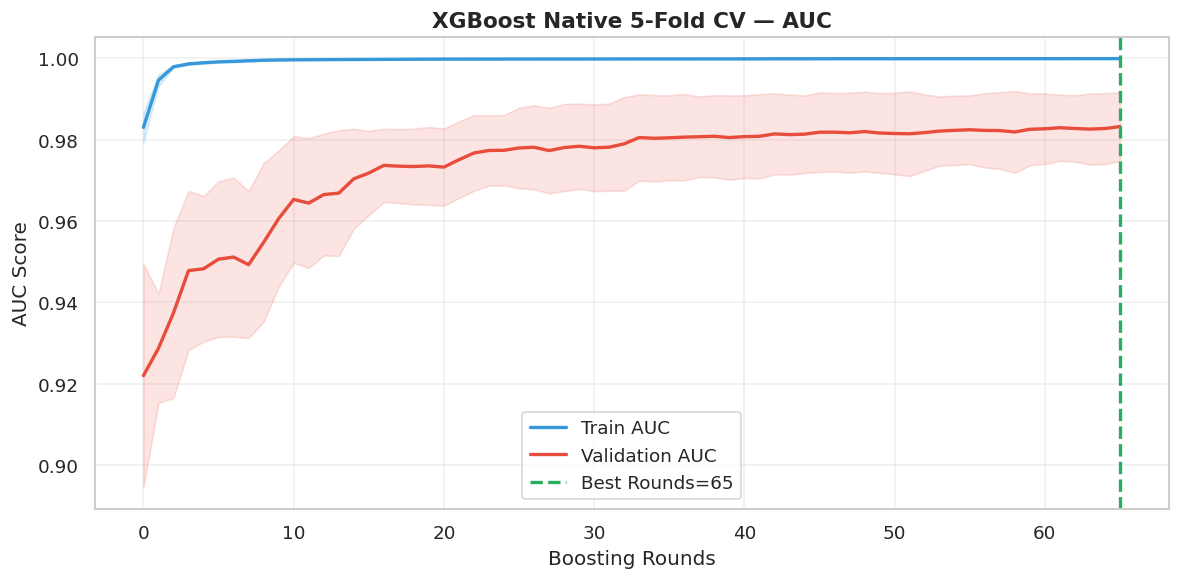

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(cv_results.index,
        cv_results['train-auc-mean'],
        color='#3498db', lw=2,
        label='Train AUC')
ax.fill_between(
    cv_results.index,
    cv_results['train-auc-mean'] -
    cv_results['train-auc-std'],
    cv_results['train-auc-mean'] +
    cv_results['train-auc-std'],
    alpha=0.15, color='#3498db')

ax.plot(cv_results.index,
        cv_results['test-auc-mean'],
        color='#e74c3c', lw=2,
        label='Validation AUC')
ax.fill_between(
    cv_results.index,
    cv_results['test-auc-mean'] -
    cv_results['test-auc-std'],
    cv_results['test-auc-mean'] +
    cv_results['test-auc-std'],
    alpha=0.15, color='#e74c3c')

ax.axvline(x=best_n_rounds,
           color='#27ae60',
           linestyle='--', lw=2,
           label=f'Best Rounds={best_n_rounds}')
ax.set_title('XGBoost Native 5-Fold CV — AUC',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Boosting Rounds')
ax.set_ylabel('AUC Score')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('XGB_09_native_cv.png',
            bbox_inches='tight')
plt.show()

In [26]:
param_dist = {
    'n_estimators'      : [100, 200, 300],
    'learning_rate'     : [0.01, 0.05],
    'max_depth'         : [3, 4, 5],
    'min_child_weight'  : [1, 3, 5],
    'gamma'             : [0, 0.1, 0.2],
    'subsample'         : [0.6, 0.7],
    'colsample_bytree'  : [0.6, 0.7],
    'reg_alpha'         : [0, 0.01],
    'reg_lambda'        : [0.5, 1.0],
}

rand_search = RandomizedSearchCV(
    estimator = XGBClassifier(
        scale_pos_weight  = scale_pos_weight,
        use_label_encoder = False,
        eval_metric       = 'auc',
        random_state      = 42,
        n_jobs            = -1),
    param_distributions = param_dist,
    n_iter       = 2,
    cv           = StratifiedKFold(2),
    scoring      = 'roc_auc',
    random_state = 42,
    n_jobs       = -1,
    verbose      = 1)

rand_search.fit(X_train, y_train)

print(f"\n✅ Best Params (Random): "
      f"{rand_search.best_params_}")
print(f"✅ Best CV ROC-AUC     : "
      f"{rand_search.best_score_:.4f}")

Fitting 2 folds for each of 2 candidates, totalling 4 fits

✅ Best Params (Random): {'subsample': 0.6, 'reg_lambda': 1.0, 'reg_alpha': 0.01, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.2, 'colsample_bytree': 0.6}
✅ Best CV ROC-AUC     : 0.9828


In [30]:
bp = rand_search.best_params_

param_grid = {
    'n_estimators': [bp['n_estimators']],
    'learning_rate': [
        bp['learning_rate'],
        min(1.0, bp['learning_rate'] + 0.02)
    ],
    'max_depth': [
        bp['max_depth'],
        bp['max_depth'] + 1
    ],
    'min_child_weight': [bp['min_child_weight']],
    'gamma': [bp['gamma']],
    'subsample': [bp['subsample']],
    'colsample_bytree': [bp['colsample_bytree']],
    'reg_alpha': [bp['reg_alpha']],
    'reg_lambda': [bp['reg_lambda']]
}

grid_search = GridSearchCV(
    estimator = XGBClassifier(
        scale_pos_weight  = scale_pos_weight,
        use_label_encoder = False,
        eval_metric       = 'auc',
        random_state      = 42,
        n_jobs            = -1),
    param_grid   = param_grid,
    cv           = StratifiedKFold(2),
    scoring      = 'roc_auc',
    n_jobs       = -1,
    verbose      = 1)

grid_search.fit(X_train, y_train)

print(f"\n✅ Best Params (Grid): "
      f"{grid_search.best_params_}")
print(f"✅ Best CV ROC-AUC   : "
      f"{grid_search.best_score_:.4f}")

Fitting 2 folds for each of 4 candidates, totalling 8 fits

✅ Best Params (Grid): {'colsample_bytree': 0.6, 'gamma': 0.2, 'learning_rate': 0.05, 'max_depth': 6, 'min_child_weight': 5, 'n_estimators': 300, 'reg_alpha': 0.01, 'reg_lambda': 1.0, 'subsample': 0.6}
✅ Best CV ROC-AUC   : 0.9835


In [31]:
xgb_best = grid_search.best_estimator_
xgb_best.fit(
    X_train, y_train,
    eval_set        = [(X_train, y_train),
                       (X_test,  y_test)],
    verbose         = False)

y_pred      = xgb_best.predict(X_test)
y_pred_prob = xgb_best.predict_proba(
    X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_pred_prob)
apr = average_precision_score(y_test, y_pred_prob)
cv  = cross_val_score(
    xgb_best, X_train, y_train,
    cv      = StratifiedKFold(5),
    scoring = 'roc_auc')

print(f"\n{'Metric':<30} {'Baseline':>10} "
      f"{'Tuned':>10}")
print("-" * 52)
print(f"{'Accuracy':<30} "
      f"{acc_base*100:>9.2f}% {acc*100:>9.2f}%")
print(f"{'ROC-AUC':<30} "
      f"{roc_base:>10.4f} {roc:>10.4f}")
print(f"{'Avg Precision (PR-AUC)':<30} "
      f"{apr_base:>10.4f} {apr:>10.4f}")
print(f"{'CV ROC-AUC (mean)':<30} "
      f"{'—':>10} {cv.mean():>10.4f}")
print(f"{'CV ROC-AUC (std)':<30} "
      f"{'—':>10} {cv.std():>10.4f}")

print(f"\n📋 Classification Report:\n")
print(classification_report(
    y_test, y_pred,
    target_names=['Legitimate', 'Fraud']))


Metric                           Baseline      Tuned
----------------------------------------------------
Accuracy                           99.93%     99.95%
ROC-AUC                            0.9653     0.9731
Avg Precision (PR-AUC)             0.7978     0.8151
CV ROC-AUC (mean)                       —     0.9812
CV ROC-AUC (std)                        —     0.0106

📋 Classification Report:

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.88      0.80      0.84        95

    accuracy                           1.00     56746
   macro avg       0.94      0.90      0.92     56746
weighted avg       1.00      1.00      1.00     56746



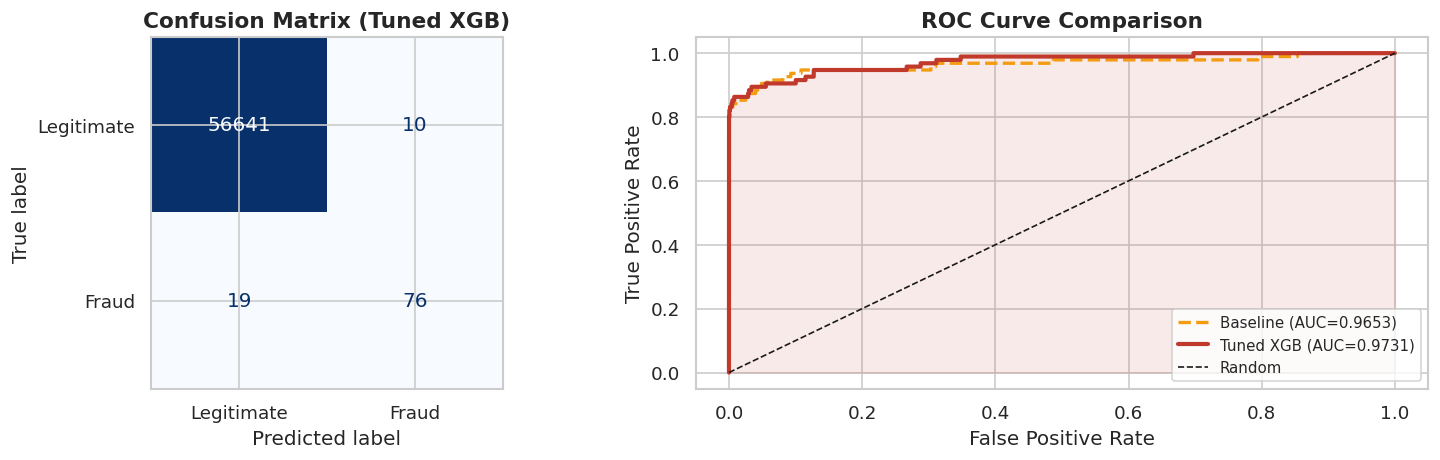

💾 Saved: XGB_10_confusion_roc.png


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels   = ['Legitimate', 'Fraud'])
disp.plot(ax=axes[0], colorbar=False,
          cmap='Blues')
axes[0].set_title('Confusion Matrix (Tuned XGB)',
                  fontsize=13, fontweight='bold')

# ROC Curves
fpr_b, tpr_b, _ = roc_curve(y_test, y_prob_base)
fpr_t, tpr_t, _ = roc_curve(y_test, y_pred_prob)

axes[1].plot(fpr_b, tpr_b,
             color='#f39c12', lw=2,
             linestyle='--',
             label=f'Baseline '
                   f'(AUC={roc_base:.4f})')
axes[1].plot(fpr_t, tpr_t,
             color='#c0392b', lw=2.5,
             label=f'Tuned XGB '
                   f'(AUC={roc:.4f})')
axes[1].fill_between(fpr_t, tpr_t,
                     alpha=0.1, color='#c0392b')
axes[1].plot([0,1],[0,1], 'k--',
             lw=1, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve Comparison',
                  fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('XGB_10_confusion_roc.png',
            bbox_inches='tight')
plt.show()
print("💾 Saved: XGB_10_confusion_roc.png")

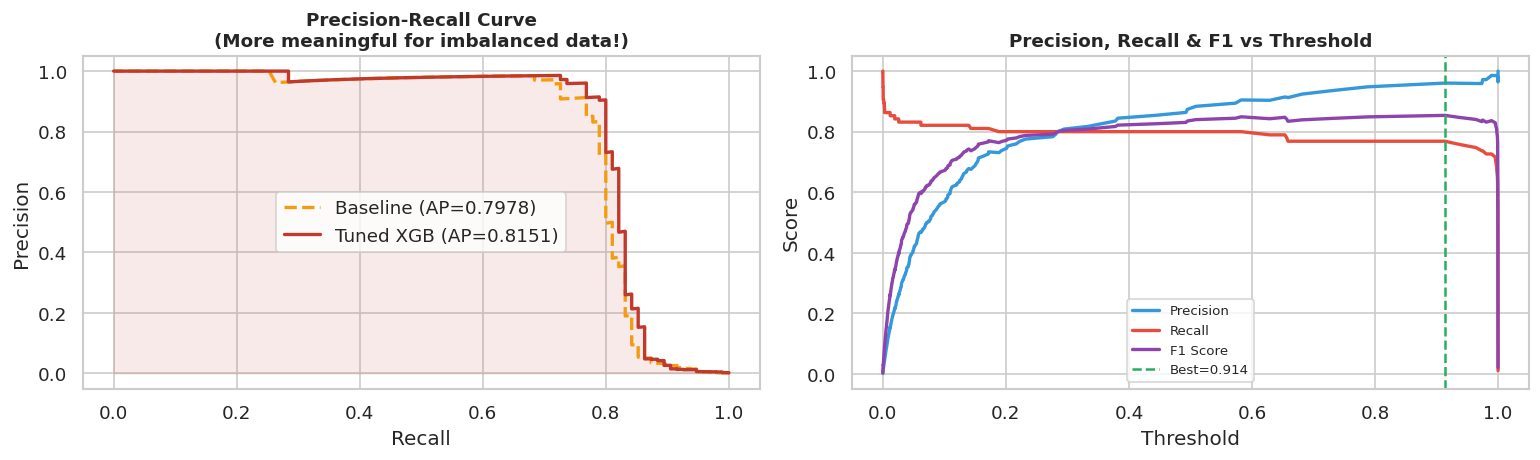

💾 Saved: XGB_11_precision_recall.png
📌 Best F1 Threshold: 0.9139


In [33]:
precision, recall, thresholds = precision_recall_curve(
    y_test, y_pred_prob)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# PR Curve
pr_b, rc_b, _ = precision_recall_curve(
    y_test, y_prob_base)
axes[0].plot(rc_b, pr_b,
             color='#f39c12', lw=2,
             linestyle='--',
             label=f'Baseline '
                   f'(AP={apr_base:.4f})')
axes[0].plot(recall, precision,
             color='#c0392b', lw=2,
             label=f'Tuned XGB '
                   f'(AP={apr:.4f})')
axes[0].fill_between(recall, precision,
                     alpha=0.1, color='#c0392b')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve\n'
                  '(More meaningful for imbalanced data!)',
                  fontsize=11, fontweight='bold')
axes[0].legend()

# Threshold Analysis
f1 = (2 * precision[:-1] * recall[:-1] /
      (precision[:-1] + recall[:-1] + 1e-8))
best_thresh = thresholds[np.argmax(f1)]

axes[1].plot(thresholds, precision[:-1],
             color='#3498db', lw=2,
             label='Precision')
axes[1].plot(thresholds, recall[:-1],
             color='#e74c3c', lw=2,
             label='Recall')
axes[1].plot(thresholds, f1,
             color='#8e44ad', lw=2,
             label='F1 Score')
axes[1].axvline(x=best_thresh,
                color='#27ae60',
                linestyle='--',
                label=f'Best='
                      f'{best_thresh:.3f}')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision, Recall & F1 '
                  'vs Threshold',
                  fontsize=11, fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('XGB_11_precision_recall.png',
            bbox_inches='tight')
plt.show()
print("💾 Saved: XGB_11_precision_recall.png")
print(f"📌 Best F1 Threshold: {best_thresh:.4f}")

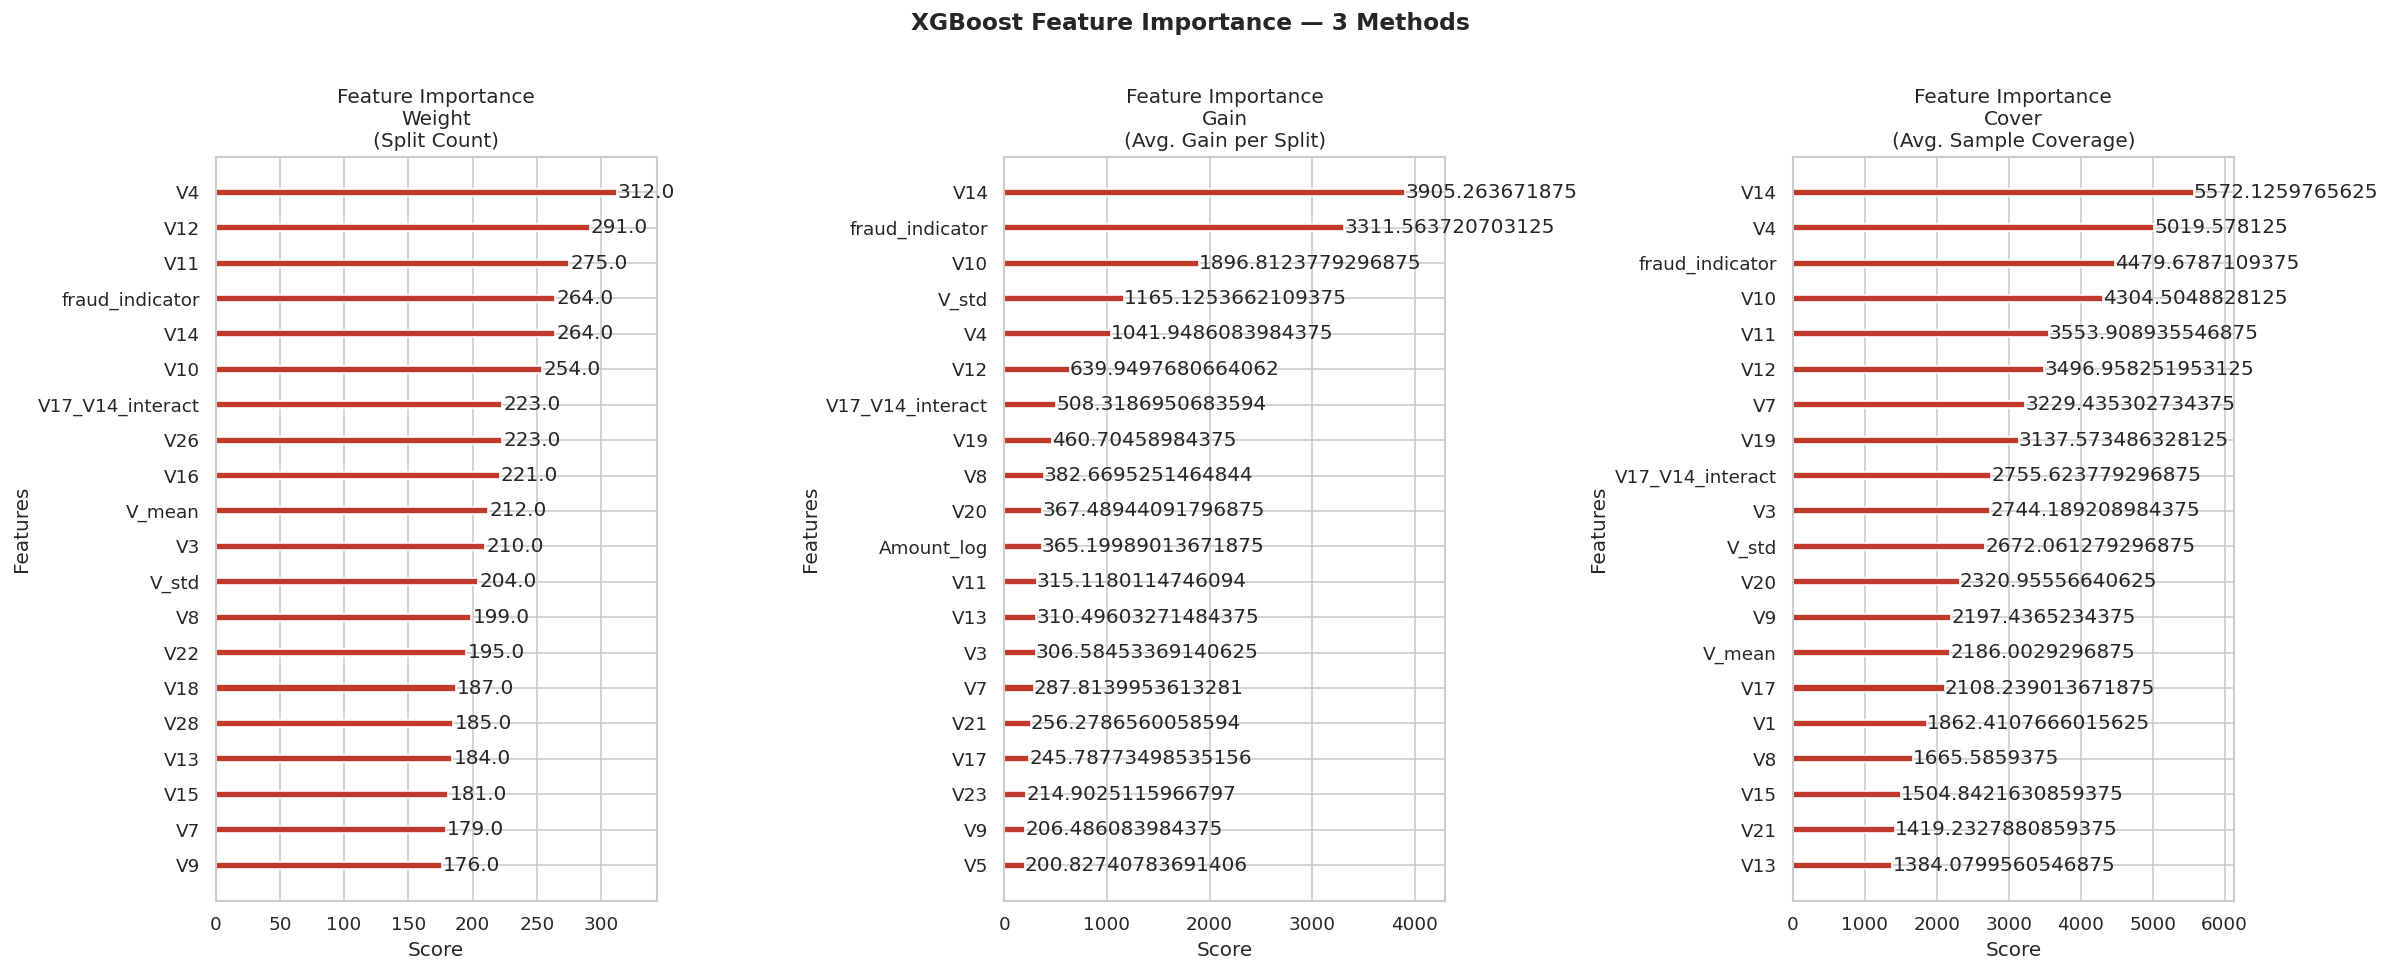

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

importance_types = ['weight', 'gain', 'cover']
titles = ['Weight\n(Split Count)',
          'Gain\n(Avg. Gain per Split)',
          'Cover\n(Avg. Sample Coverage)']

for ax, imp_type, title in zip(
        axes, importance_types, titles):
    xgb.plot_importance(
        xgb_best,
        importance_type = imp_type,
        max_num_features= 20,
        ax              = ax,
        color           = '#c0392b',
        title           = f'Feature Importance\n{title}')
    ax.set_xlabel('Score')

plt.suptitle('XGBoost Feature Importance '
             '— 3 Methods',
             fontsize=14, fontweight='bold',
             y=1.01)
plt.tight_layout()
plt.savefig('XGB_12_feature_importance.png',
            bbox_inches='tight')
plt.show()

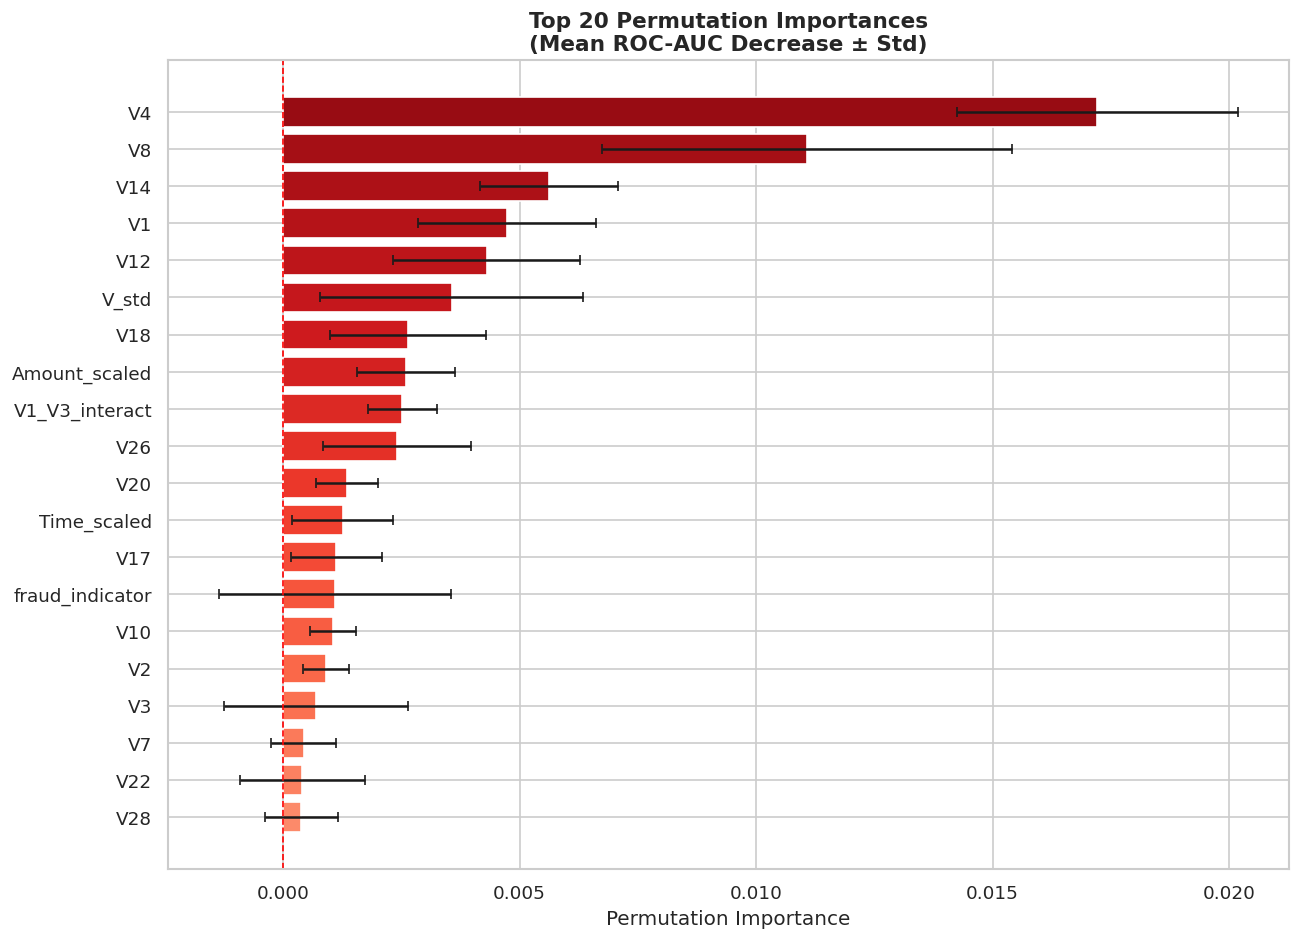

In [35]:
perm_imp = permutation_importance(
    xgb_best, X_test, y_test,
    n_repeats    = 10,
    random_state = 42,
    scoring      = 'roc_auc',
    n_jobs       = -1)

feature_names = X.columns.tolist()
perm_df = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': perm_imp.importances_mean,
    'Std'       : perm_imp.importances_std
}).sort_values('Importance',
               ascending=False).head(20)

fig, ax = plt.subplots(figsize=(11, 8))
colors  = plt.cm.Reds(
    np.linspace(0.4, 0.9, len(perm_df)))[::-1]

ax.barh(perm_df['Feature'],
        perm_df['Importance'],
        xerr=perm_df['Std'],
        color=colors,
        edgecolor='white',
        capsize=3)
ax.set_title('Top 20 Permutation Importances\n'
             '(Mean ROC-AUC Decrease ± Std)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Permutation Importance')
ax.axvline(x=0, color='red',
           linestyle='--', linewidth=1)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('XGB_13_permutation_importance.png',
            bbox_inches='tight')
plt.show()

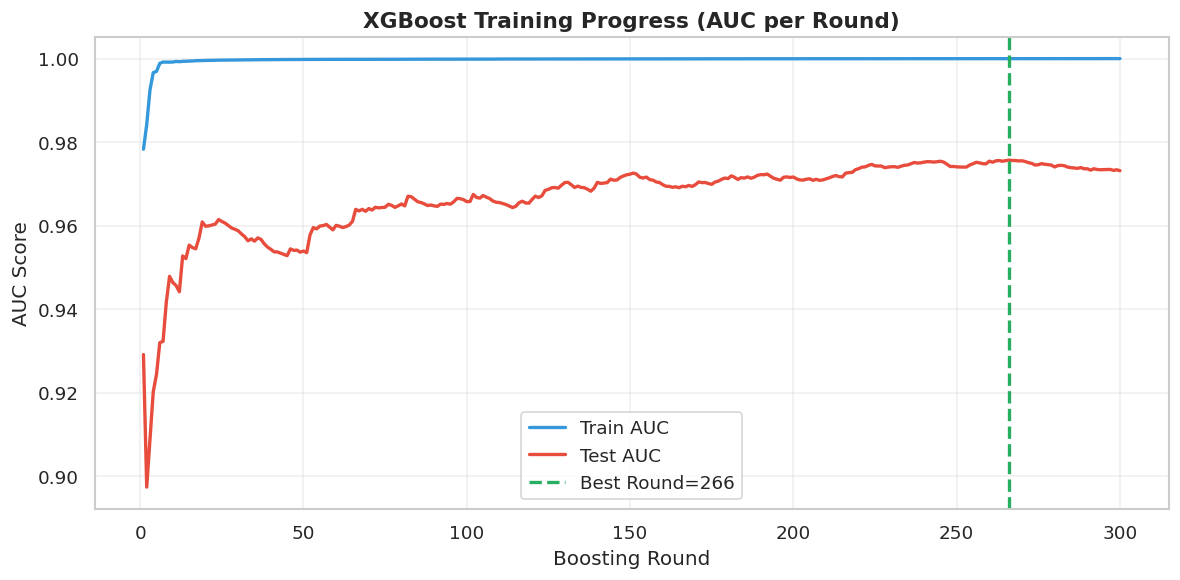

In [36]:
evals_result = xgb_best.evals_result()

fig, ax = plt.subplots(figsize=(10, 5))

train_auc = evals_result['validation_0']['auc']
test_auc  = evals_result['validation_1']['auc']
rounds    = range(1, len(train_auc) + 1)

ax.plot(rounds, train_auc,
        color='#3498db', lw=2,
        label='Train AUC')
ax.plot(rounds, test_auc,
        color='#e74c3c', lw=2,
        label='Test AUC')
ax.axvline(
    x=np.argmax(test_auc) + 1,
    color='#27ae60', linestyle='--', lw=2,
    label=f'Best Round='
          f'{np.argmax(test_auc) + 1}')
ax.set_title('XGBoost Training Progress '
             '(AUC per Round)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('AUC Score')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('XGB_14_training_curve.png',
            bbox_inches='tight')
plt.show()

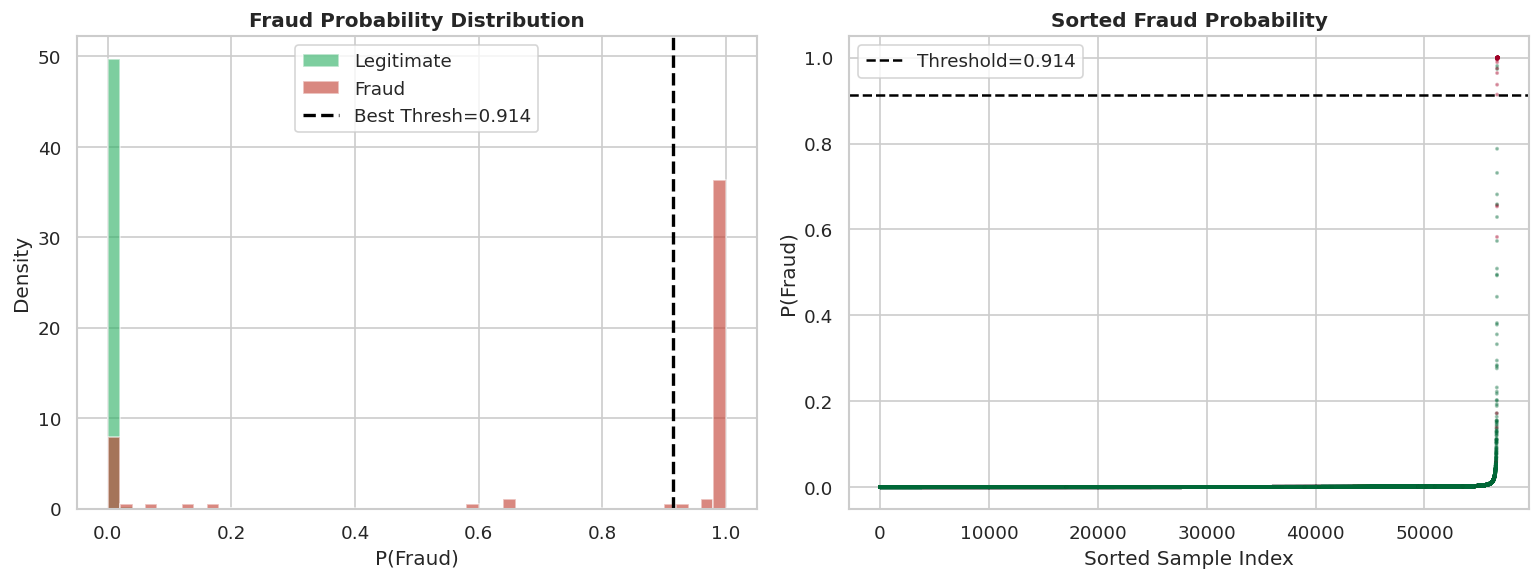

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Score distribution
axes[0].hist(
    y_pred_prob[y_test == 0],
    bins=50, alpha=0.6,
    color='#27ae60',
    label='Legitimate',
    density=True)
axes[0].hist(
    y_pred_prob[y_test == 1],
    bins=50, alpha=0.6,
    color='#c0392b',
    label='Fraud',
    density=True)
axes[0].axvline(x=best_thresh,
                color='black',
                linestyle='--', lw=2,
                label=f'Best Thresh='
                      f'{best_thresh:.3f}')
axes[0].set_title('Fraud Probability Distribution',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('P(Fraud)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Calibration-like plot
sorted_idx = np.argsort(y_pred_prob)
axes[1].scatter(
    range(len(y_test)),
    y_pred_prob[sorted_idx],
    c=y_test.values[sorted_idx],
    cmap='RdYlGn_r',
    alpha=0.3, s=2)
axes[1].axhline(y=best_thresh,
                color='black',
                linestyle='--', lw=1.5,
                label=f'Threshold='
                      f'{best_thresh:.3f}')
axes[1].set_title('Sorted Fraud Probability',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sorted Sample Index')
axes[1].set_ylabel('P(Fraud)')
axes[1].legend()

plt.tight_layout()
plt.savefig('XGB_15_prob_distribution.png',
            bbox_inches='tight')
plt.show()

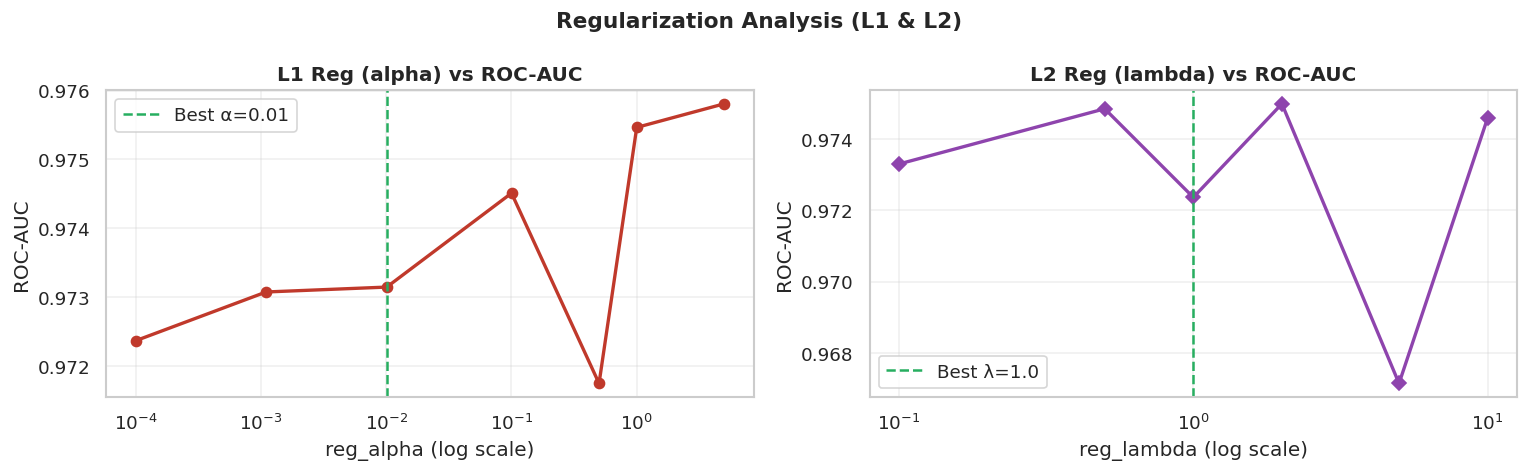

In [42]:
alphas  = [0, 0.001, 0.01, 0.1, 0.5, 1.0, 5.0]
lambdas = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]

alpha_roc  = []
lambda_roc = []

# Create a copy of best_params_ and remove reg_alpha and reg_lambda
base_params = {k: v for k, v in grid_search.best_params_.items()}
base_params.pop('reg_alpha', None)
base_params.pop('reg_lambda', None)

for a in alphas:
    m = XGBClassifier(
        **base_params,
        reg_alpha        = a,
        scale_pos_weight = scale_pos_weight,
        use_label_encoder= False,
        eval_metric      = 'auc',
        random_state     = 42,
        n_jobs           = -1)
    m.fit(X_train, y_train, verbose=False)
    alpha_roc.append(roc_auc_score(
        y_test,
        m.predict_proba(X_test)[:, 1]))

for l in lambdas:
    m = XGBClassifier(
        **base_params,
        reg_lambda       = l,
        scale_pos_weight = scale_pos_weight,
        use_label_encoder= False,
        eval_metric      = 'auc',
        random_state     = 42,
        n_jobs           = -1)
    m.fit(X_train, y_train, verbose=False)
    lambda_roc.append(roc_auc_score(
        y_test,
        m.predict_proba(X_test)[:, 1]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].semilogx(
    [a + 1e-4 for a in alphas],
    alpha_roc, 'o-',
    color='#c0392b', lw=2)
axes[0].axvline(
    x=max(1e-4,
          grid_search.best_params_['reg_alpha']
          + 1e-4),
    color='#27ae60', linestyle='--',
    label=f'Best α='
          f'{grid_search.best_params_["reg_alpha"]}')
axes[0].set_title('L1 Reg (alpha) vs ROC-AUC',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('reg_alpha (log scale)')
axes[0].set_ylabel('ROC-AUC')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].semilogx(lambdas, lambda_roc, 'D-',
                 color='#8e44ad', lw=2)
axes[1].axvline(
    x=grid_search.best_params_['reg_lambda'],
    color='#27ae60', linestyle='--',
    label=f'Best λ='
          f'{grid_search.best_params_["reg_lambda"]}')
axes[1].set_title('L2 Reg (lambda) vs ROC-AUC',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('reg_lambda (log scale)')
axes[1].set_ylabel('ROC-AUC')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Regularization Analysis (L1 & L2)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('XGB_16_regularization.png',
            bbox_inches='tight')
plt.show()

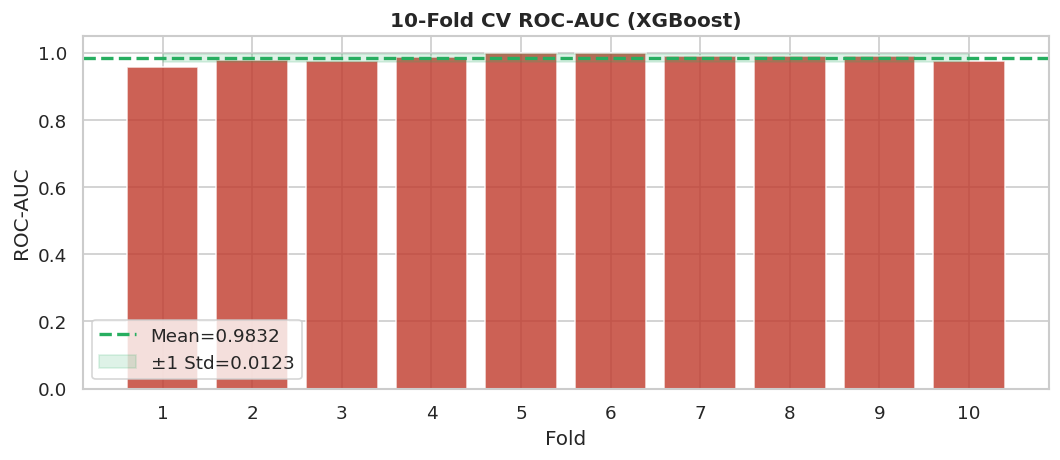

In [43]:
cv_scores_10 = cross_val_score(
    xgb_best, X_train, y_train,
    cv=StratifiedKFold(10),
    scoring='roc_auc')

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(1, 11), cv_scores_10,
       color='#c0392b',
       edgecolor='white', alpha=0.8)
ax.axhline(y=cv_scores_10.mean(),
           color='#27ae60',
           linestyle='--', lw=2,
           label=f'Mean='
                 f'{cv_scores_10.mean():.4f}')
ax.fill_between(
    range(1, 11),
    cv_scores_10.mean() - cv_scores_10.std(),
    cv_scores_10.mean() + cv_scores_10.std(),
    alpha=0.15, color='#27ae60',
    label=f'±1 Std='
          f'{cv_scores_10.std():.4f}')
ax.set_title('10-Fold CV ROC-AUC (XGBoost)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Fold')
ax.set_ylabel('ROC-AUC')
ax.set_xticks(range(1, 11))
ax.legend()
plt.tight_layout()
plt.savefig('XGB_17_cv_scores.png',
            bbox_inches='tight')
plt.show()

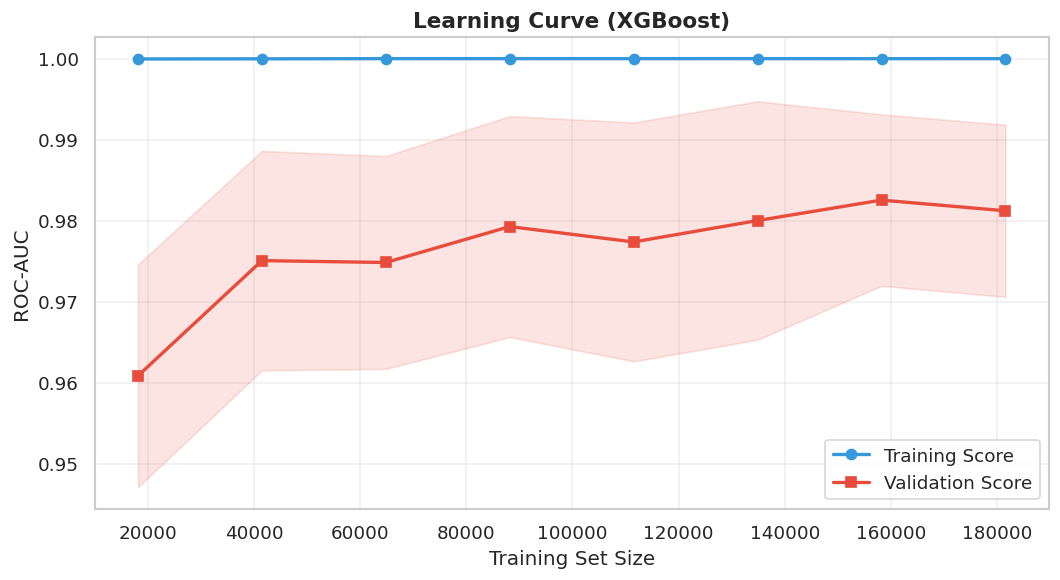

In [44]:
train_sizes, train_sc, val_sc = learning_curve(
    xgb_best, X_train, y_train,
    train_sizes = np.linspace(0.1, 1.0, 8),
    cv          = StratifiedKFold(5),
    scoring     = 'roc_auc',
    n_jobs      = -1)

train_mean = train_sc.mean(axis=1)
train_std  = train_sc.std(axis=1)
val_mean   = val_sc.mean(axis=1)
val_std    = val_sc.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_mean,
        'o-', color='#3498db', lw=2,
        label='Training Score')
ax.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15, color='#3498db')
ax.plot(train_sizes, val_mean,
        's-', color='#e74c3c', lw=2,
        label='Validation Score')
ax.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.15, color='#e74c3c')
ax.set_title('Learning Curve (XGBoost)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Training Set Size')
ax.set_ylabel('ROC-AUC')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('XGB_18_learning_curve.png',
            bbox_inches='tight')
plt.show()

In [45]:
y_pred_optimal = (y_pred_prob >= best_thresh).astype(int)
acc_opt = accuracy_score(y_test, y_pred_optimal)
roc_opt = roc_auc_score(y_test, y_pred_prob)

print(f"Default  Threshold (0.50) → "
      f"Accuracy: {acc*100:.2f}%")
print(f"Optimal  Threshold "
      f"({best_thresh:.3f}) → "
      f"Accuracy: {acc_opt*100:.2f}%")

print(f"\n📋 Report with Optimal Threshold:\n")
print(classification_report(
    y_test, y_pred_optimal,
    target_names=['Legitimate', 'Fraud']))

Default  Threshold (0.50) → Accuracy: 99.95%
Optimal  Threshold (0.914) → Accuracy: 99.96%

📋 Report with Optimal Threshold:

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.96      0.77      0.85        95

    accuracy                           1.00     56746
   macro avg       0.98      0.88      0.93     56746
weighted avg       1.00      1.00      1.00     56746



In [46]:
# Save XGBoost model (sklearn format)
joblib.dump(xgb_best,
            'xgb_fraud_model.pkl')
print("✅ XGB Model (pkl)     → xgb_fraud_model.pkl")

# Save XGBoost native format
xgb_best.save_model('xgb_fraud_model.json')
print("✅ XGB Model (json)    → xgb_fraud_model.json")

# Save scaler
joblib.dump(scaler_amount,
            'XGB_amount_scaler.pkl')
print("✅ Amount Scaler       → XGB_amount_scaler.pkl")

# Save feature names
pd.DataFrame({
    'features': feature_names
}).to_csv('XGB_feature_names.csv', index=False)
print("✅ Features            → XGB_feature_names.csv")

# Save all importances
imp_weight = xgb_best.get_booster(
    ).get_score(importance_type='weight')
imp_gain   = xgb_best.get_booster(
    ).get_score(importance_type='gain')
imp_cover  = xgb_best.get_booster(
    ).get_score(importance_type='cover')

feat_imp_df = pd.DataFrame({
    'Feature'    : list(imp_gain.keys()),
    'Weight'     : [imp_weight.get(f, 0)
                    for f in imp_gain.keys()],
    'Gain'       : list(imp_gain.values()),
    'Cover'      : [imp_cover.get(f, 0)
                    for f in imp_gain.keys()],
    'Permutation': perm_imp.importances_mean[
                    :len(imp_gain)]
}).sort_values('Gain', ascending=False)
feat_imp_df.to_csv(
    'XGB_feature_importances.csv', index=False)
print("✅ Importances         → "
      "XGB_feature_importances.csv")

# Save CV results
cv_results.to_csv(
    'XGB_native_cv_results.csv', index=False)
print("✅ Native CV results   → "
      "XGB_native_cv_results.csv")

# Save GridSearch results
pd.DataFrame(
    grid_search.cv_results_
).to_csv('XGB_gridsearch_results.csv', index=False)
print("✅ GridSearch results  → "
      "XGB_gridsearch_results.csv")

# Save threshold info
pd.DataFrame({
    'threshold'  : thresholds,
    'precision'  : precision[:-1],
    'recall'     : recall[:-1],
    'f1'         : f1
}).to_csv('XGB_threshold_analysis.csv', index=False)
print("✅ Threshold analysis  → "
      "XGB_threshold_analysis.csv")

# ── Download in Google Colab ──────────────────────────────────
try:
    from google.colab import files
    files.download('xgb_fraud_model.pkl')
    files.download('xgb_fraud_model.json')
    files.download('XGB_amount_scaler.pkl')
    files.download('XGB_feature_names.csv')
    files.download('XGB_feature_importances.csv')
    files.download('XGB_native_cv_results.csv')
    files.download('XGB_gridsearch_results.csv')
    files.download('XGB_threshold_analysis.csv')
    print("\n🎉 All files downloaded!")
except ImportError:
    print("\n📁 Saved locally:")
    print(f"   → "
          f"{os.path.abspath('xgb_fraud_model.pkl')}")
    print(f"   → "
          f"{os.path.abspath('xgb_fraud_model.json')}")

✅ XGB Model (pkl)     → xgb_fraud_model.pkl
✅ XGB Model (json)    → xgb_fraud_model.json
✅ Amount Scaler       → XGB_amount_scaler.pkl
✅ Features            → XGB_feature_names.csv
✅ Importances         → XGB_feature_importances.csv
✅ Native CV results   → XGB_native_cv_results.csv
✅ GridSearch results  → XGB_gridsearch_results.csv
✅ Threshold analysis  → XGB_threshold_analysis.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 All files downloaded!


In [47]:
# Load pkl model
loaded_pkl  = joblib.load('xgb_fraud_model.pkl')

# Load json model
loaded_json = XGBClassifier()
loaded_json.load_model('xgb_fraud_model.json')

sample      = X_test.iloc[:6]
predictions = loaded_pkl.predict(sample)
proba       = loaded_pkl.predict_proba(
    sample)[:, 1]
pred_opt    = (proba >= best_thresh).astype(int)
actuals     = y_test.values[:6]

print("\n📊 Predictions (Default vs Optimal Threshold):")
print(f"{'#':<4} {'Default(0.5)':<16} "
      f"{'Optimal':<16} "
      f"{'P(Fraud)':>10} {'Actual':>12}")
print("-" * 62)

for i, (pred, pred_o, prob, actual) in enumerate(
        zip(predictions, pred_opt,
            proba, actuals)):
    d_label  = ("🔴 FRAUD"
                if pred   == 1
                else "🟢 LEGIT")
    o_label  = ("🔴 FRAUD"
                if pred_o == 1
                else "🟢 LEGIT")
    act_lbl  = ("FRAUD"
                if actual == 1
                else "LEGIT")
    correct  = "✅" if pred_o == actual else "❌"
    print(f"{i+1:<4} {d_label:<16} "
          f"{o_label:<16} "
          f"{prob*100:>9.4f}% "
          f"{act_lbl:>10} {correct}")

print("\n Both models loaded and working!")


📊 Predictions (Default vs Optimal Threshold):
#    Default(0.5)     Optimal            P(Fraud)       Actual
--------------------------------------------------------------
1    🟢 LEGIT          🟢 LEGIT             0.0010%      LEGIT ✅
2    🟢 LEGIT          🟢 LEGIT             0.0035%      LEGIT ✅
3    🟢 LEGIT          🟢 LEGIT             0.0367%      LEGIT ✅
4    🟢 LEGIT          🟢 LEGIT             0.0159%      LEGIT ✅
5    🟢 LEGIT          🟢 LEGIT             0.0548%      LEGIT ✅
6    🟢 LEGIT          🟢 LEGIT             0.0226%      LEGIT ✅

 Both models loaded and working!


In [48]:
print(f"  Dataset              : Credit Card Fraud")
print(f"  Dataset Shape        : {df.shape}")
print(f"  Features Used        : {X.shape[1]}")
print(f"  Training Samples     : {X_train.shape[0]:,}")
print(f"  Test Samples         : {X_test.shape[0]:,}")
print(f"  Fraud Rate           : {y.mean()*100:.4f}%")
print(f"  scale_pos_weight     : {scale_pos_weight:.2f}")
print(f"  Best Parameters      : "
      f"{grid_search.best_params_}")
print(f"  Baseline ROC-AUC     : {roc_base:.4f}")
print(f"  Tuned ROC-AUC        : {roc:.4f}")
print(f"  PR-AUC (Avg Prec)    : {apr:.4f}")
print(f"  CV ROC-AUC           : "
      f"{cv.mean():.4f} ± {cv.std():.4f}")
print(f"  Best F1 Threshold    : {best_thresh:.4f}")
print(f"  Native CV Best Round : {best_n_rounds}")
print(f"  Native CV Best AUC   : {best_cv_auc:.4f}")

print(" Saved Files:")
print("   xgb_fraud_model.pkl   ← sklearn format")
print("   xgb_fraud_model.json  ← native format")
print("   XGB_amount_scaler.pkl")
print("   XGB_feature_names.csv")
print("   XGB_feature_importances.csv")
print("   XGB_native_cv_results.csv")
print("   XGB_gridsearch_results.csv")
print("   XGB_threshold_analysis.csv")
print("    XGB_01 ~ XGB_18 PNG files")

print(" XGBoost Pipeline Complete! ")

  Dataset              : Credit Card Fraud
  Dataset Shape        : (283726, 32)
  Features Used        : 36
  Training Samples     : 226,980
  Test Samples         : 56,746
  Fraud Rate           : 0.1667%
  scale_pos_weight     : 599.48
  Best Parameters      : {'colsample_bytree': 0.6, 'gamma': 0.2, 'learning_rate': 0.05, 'max_depth': 6, 'min_child_weight': 5, 'n_estimators': 300, 'reg_alpha': 0.01, 'reg_lambda': 1.0, 'subsample': 0.6}
  Baseline ROC-AUC     : 0.9653
  Tuned ROC-AUC        : 0.9731
  PR-AUC (Avg Prec)    : 0.8151
  CV ROC-AUC           : 0.9812 ± 0.0106
  Best F1 Threshold    : 0.9139
  Native CV Best Round : 65
  Native CV Best AUC   : 0.9832
 Saved Files:
   xgb_fraud_model.pkl   ← sklearn format
   xgb_fraud_model.json  ← native format
   XGB_amount_scaler.pkl
   XGB_feature_names.csv
   XGB_feature_importances.csv
   XGB_native_cv_results.csv
   XGB_gridsearch_results.csv
   XGB_threshold_analysis.csv
    XGB_01 ~ XGB_18 PNG files
 XGBoost Pipeline Complete! 
